<center>
   <img src="../logounam.png"width="150">
</center>


  <font size="6"><b> <center> Universidad Nacional Autónoma de México     </b> <br> </font>
  <font size="4"><b> <center> Posgrado en Ciencias de la Tierra </b><br> </font>
  <font size="3"> <center> Unet1D implementation for Regional Seismic Phase Picking in Paricutin Data Engineering  </b> <br> </font>
  <font size="3"><b> <center>@Author: MSc. Kevin Axel Vargas-Zamudio </b> <br> </font>
  <font size="3"><b> <center>email: seismo.ai.kevvargas@gmail.com </b><br></font>
 

# Observed data for 2022 Paricutin Seismic Swarm
## Reduced label samples
## 1D CNN development for Regional Seismic Phase Picking with Feature Engineering
### Unet adaptation for time series phase determination

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from scipy.io import loadmat,savemat
from scipy.signal import hilbert
from scipy.fft import fft,ifft,fftfreq

from os.path import dirname, join as pjoin
import sys
import copy as copy
import os
import time
import random

/home/kvargasz/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/kvargasz/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
#!pip install tensorflow==2.12.0

In [3]:
path = '/StorageCitlalli/Paricutin/EnjambreParicutin/CNN1D/CNN1D_env'
l_path = '/SeismoAI/Datos_Sismicos/Datos_Reales/Paricutin_CNN/Phase Picking CNN1D-RNN/Modules/'
sys.path.append(path + l_path)
os.path.basename(path + l_path)

# Module subroutine importation
import Module_Unet1D_NN_Imp as nimp

### Curating signals: bad signals and no gaussian mask

## Reading X input and y target

In [4]:
months , day_30, day_31 = nimp.month_day_str()
years = ['2022', '2023']

# loading X_input Signal
path = '../X_input_mat/'
data,data_day,data_time = nimp.retrieve_Xinput_Ytarget(years,months,day_30,day_31,path)

Xinput = []
ytarget = []

for i in range(len(data)):
    Xinput.append(data[i]['Xinput'])
    ytarget.append(data[i]['Ytarget'])


Nsamp_win = len(data[0]['Xinput'][0])
Ncomp     = data[0]['Xinput'][0].shape[-1]
Nlabels   = data[0]['Ytarget'][0][:].shape[-1]

aux = 0
for i in range(len(data)):
    aux += len(data[i]['Xinput'])
    
aux_time = 0
for i in range(len(data_time)):
    aux_time += len(data_time[i]['time'])
print(f'Number of signals (time):{aux_time}')

Number of signals (time):1940


In [5]:
# excl = [635,636,686,687,1100,1161,1246,1497]
excl = [4,13,14,15,16,17,20,21,22,25,26,27,28,33,37,38,43,44,47,52,58,59,61,65,75,76,77,78,79,80,83,85,89,91,92,
        93,94,95,100,101,113,115,116,119,122,125,129,134,136,139,140,147,153,155,158,159,164,167,175,176,177,178,
        179,181,182,189,191,194,195,198,199,202,204,209,217,219,220,226,227,231,237,254,257,258,259,263,267,272,
        274,275,279,287,292,302,306,314,319,329,336,338,339,341,344,345,346,353,354,358,359,374,498,558,561,563,572,627,
        633,634,684,685,729,790,808,810,826,844,862,919,936,943,972,976,991,997,998,1005,1045,1079,1081,1082,1094,1095,
        1098,1110,1113,1146,1158,1159,1181,1186,1198,1218,1219,1234,1235,1247,1256,1259,1261,1267,1274,1275,1313,1314,
        1322,1333,1347,1366,1377,1379,1388,1398,1413,1416,1428,1436,1450,1456,1457,1471,1484,1495,1499,1506,1523,1524,
        1531,1535,1537,1554,1557,1566,1577,1588,1592,1610,1618,1636,1641,1647,1648,1659,1667,1691,1704,1721,1743,1752,
        1754,1790,1805,1806,1828,1846,1853,1867,1868,1870,1878,1879,1888,1891,1894,1895,1909,1910,1911,1912,1917,1922,
        1923,1924,1931,1936,1937]
aux = 0
ij = []
for i in range(len(data)): # 153 days
    for j in range(len(data[i]['Xinput'])):
        if aux in excl:
            ij.append([i,j])
            aux +=1
            continue
        aux += 1
nremove = len(ij)
print(aux,nremove)

1940 235


In [6]:
X_input_1 = np.zeros((aux-nremove,Nsamp_win,Ncomp))
Y_target_1 = np.zeros((aux-nremove,Nsamp_win,Nlabels))
Time_1 = np.zeros((aux-nremove,Nsamp_win))

aux = 0
for i in range(len(data)): # 153 days
    for j in range(len(data[i]['Xinput'])): # Variable lenght: number of events 
        iijj = [i,j]
        if iijj in ij[:]:
            continue
        else:
            X_input_1[aux,:,:] = data[i]['Xinput'][j]
            Y_target_1[aux,:,:]  = data[i]['Ytarget'][j]
            Time_1[aux,:] = data_time[i]['time'][j]   
            aux += 1

print(f'Number of signals after cleaning nans and wrong examples:{aux}')

Number of signals after cleaning nans and wrong examples:1705


### Second database cleaning:

In [7]:
excl2 = [4,5,7,9,15,16,17,18,20,21,22,26,28,29,33,35,36,37,42,43,46,52,54,55,56,58,60,61,65,68,72,76,77,80,82,83,85,
        86,87,88,89,90,91,92,93,94,95,96,97,98,99,108,116,118,123,126,129,138,140,142,143,144,146,152,156,157,158,159,
        160,162,169,170,179,183,184,186,193,197,204,207,208,209,212,213,214,217,219,220,221,223,224,228,229,230,232,
        234,237,239,240,241,246,247,248,249,250,251,256,316,319,325,355,375,380,395,400,405,422,423,429,434,435,444,
        446,453,466,491,511,518,520,529,532,533,658,662,666,685,686,701,738,739,740,746,748,758,759,761,762,771,773,
        778,791,808,811,816,818,819,825,828,837,838,839,841,843,863,865,866,880,907,916,920,933,942,953,978,986,987,
        989,997,1006,1017,1027,1028,1029,1030,1031,1032,1044,1048,1049,1053,1057,1060,1062,1067,1094,1102,1143,1148,1158,
        1165,1167,1168,1170,1172,1199,1200,1201,1208,1217,1218,1219,1220,1222,1242,1251,1253,1254,1272,1277,1279,1311,
        1312,1314,1315,1325,1330,1337,1339,1340,1349,1358,1363,1379,1388,1392,1395,1397,1399,1406,1407,1408,1409,1410,
        1411,1412,1413,1417,1420,1421,1432,1440,1458,1469,1470,1471,1479,1480,1482,1484,1487,1488,1490,1492,1493,1494,
        1496,1501,1502,1505,1513,1538,1542,1544,1545,1547,1563,1568,1570,1574,1575,1580,1581,1589,1596,1598,1600,1601,
        1602,1617,1618,1619,1620,1621,1622,1625,1627,1628,1629,1633,1640,1641,1649,1657,1664,1666,1671,1679,1680,1688,
        1682,1693]

nexc = len(excl2)

N = X_input_1.shape[0]
X_input = np.zeros((N-nexc,Nsamp_win,Ncomp))
Y_target = np.zeros((N-nexc,Nsamp_win,Nlabels))
Time = np.zeros((N-nexc,Nsamp_win))

aux = 0
for i in range(N): 
    if i in excl2:
        continue
    else:
        X_input[aux,:,:] = X_input_1[i,:,:]
        Y_target[aux,:,:] = Y_target_1[i,:,:]
        Time[aux,:] = Time_1[aux,:]
        aux+=1
print(f'Number of signals after second depuration of wrong examples:{aux},{nexc}')

Number of signals after second depuration of wrong examples:1394,311


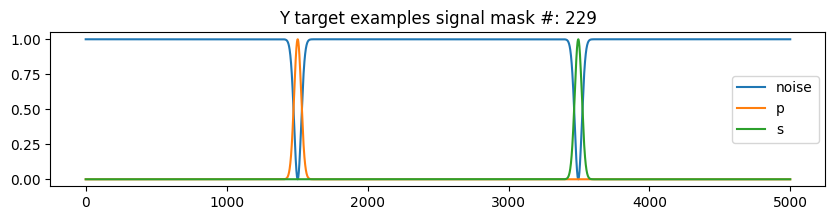

In [8]:
n = np.random.randint(X_input.shape[0])
plt.figure(figsize=(10,2))
plt.plot(Y_target[n,:,0],label='noise')
plt.plot(Y_target[n,:,1],label='p')
plt.plot(Y_target[n,:,2],label = 's')
plt.title(f'Y target examples signal mask #: {n}')
plt.legend()

In [9]:
np.where(Y_target[n,:,1] == 1.0)[0][0]

1504

### Mapping probabilites to discrete class values in Y_ target

In [10]:
Y_target_cl = np.empty_like(Y_target[:,:,:-1])
p = np.zeros((Y_target.shape[0],Y_target.shape[1]),dtype=int)
s = np.zeros((Y_target.shape[0],Y_target.shape[1]),dtype=int)

for j in range(Y_target.shape[0]):
    for i in range(Y_target.shape[1]):
        if Y_target[j,i,1] < 1e-2:
            Y_target[j,i,1] = 0.0
        if Y_target[j,i,2] < 1e-2:
            Y_target[j,i,2] = 0.0
            
            
for j in range(Y_target.shape[0]):
    for i in range(Y_target.shape[1]):
        if Y_target[j,i,1] != 0.0:
            p[j,i] = 1.0
        if Y_target[j,i,2] != 0.0:
            s[j,i] = 1.0

Y_target_cl[:,:,0] = p
Y_target_cl[:,:,1] = s

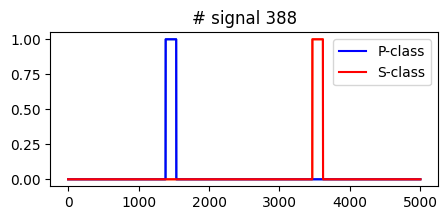

In [11]:
n = np.random.randint(X_input.shape[0])
plt.figure(figsize=(5,2))
plt.title(f'# signal {n}')
plt.plot(p[n,:])
plt.plot(s[n,:])
#plt.plot(Y_target[n,:,1])
#plt.plot(Y_target[n,:,2])

plt.plot(Y_target_cl[n,:,0],c='blue',label = 'P-class')
plt.plot(Y_target_cl[n,:,1],c='red', label = 'S-class')
plt.legend()

### Retrieving band filtered signals: 1-8, 1-2, 2-4, 4-6 Hz

In [12]:
X_input_feature = np.zeros((X_input.shape[0],X_input.shape[1],8))
print(X_input_feature.shape)
# Filtered signals between 1 and 8 Hz
X_input_feature[:,:,0] = X_input[:,:,0] # Vertical component
X_input_feature[:,:,1] = X_input[:,:,1] # North-South Component
X_input_feature[:,:,2] = X_input[:,:,2] # East-West Component

(1394, 5000, 8)


In [13]:
months , day_30, day_31 = nimp.month_day_str()
years = ['2022', '2023']
path = [f'../X_input_mat_filt_1_2Hz/',f'../X_input_mat_filt_2_4Hz/',f'../X_input_mat_filt_4_6Hz/']
X_input_filt_1 = np.zeros((X_input_1.shape[0],X_input_1.shape[1],X_input_1.shape[2],len(path)))

for f in range(len(path)):
    # loading X_input Signal
    data,data_day = nimp.retrieve_Xinput_filtered(years,months,day_30,day_31,path[f])
    Xinput = []

    for i in range(len(data)):
        Xinput.append(data[i]['Xinput'])
    aux = 0
    for i in range(len(data)): # 153 days
        for j in range(len(data[i]['Xinput'])): # Variable lenght: number of events 
            iijj = [i,j]
            if iijj in ij[:]:
                continue
            else:
                X_input_filt_1[aux,:,:,f] = data[i]['Xinput'][j]   
                aux += 1

print(f'Number of filtered signals:{aux}')

Number of filtered signals:1705


In [14]:
X_input_filt = np.zeros((X_input.shape[0],X_input.shape[1],X_input.shape[2],len(path)))

aux = 0
for i in range(N): 
    if i in excl2:
        continue
    else:
        X_input_filt[aux,:,:] = X_input_filt_1[i,:,:]
        aux+=1

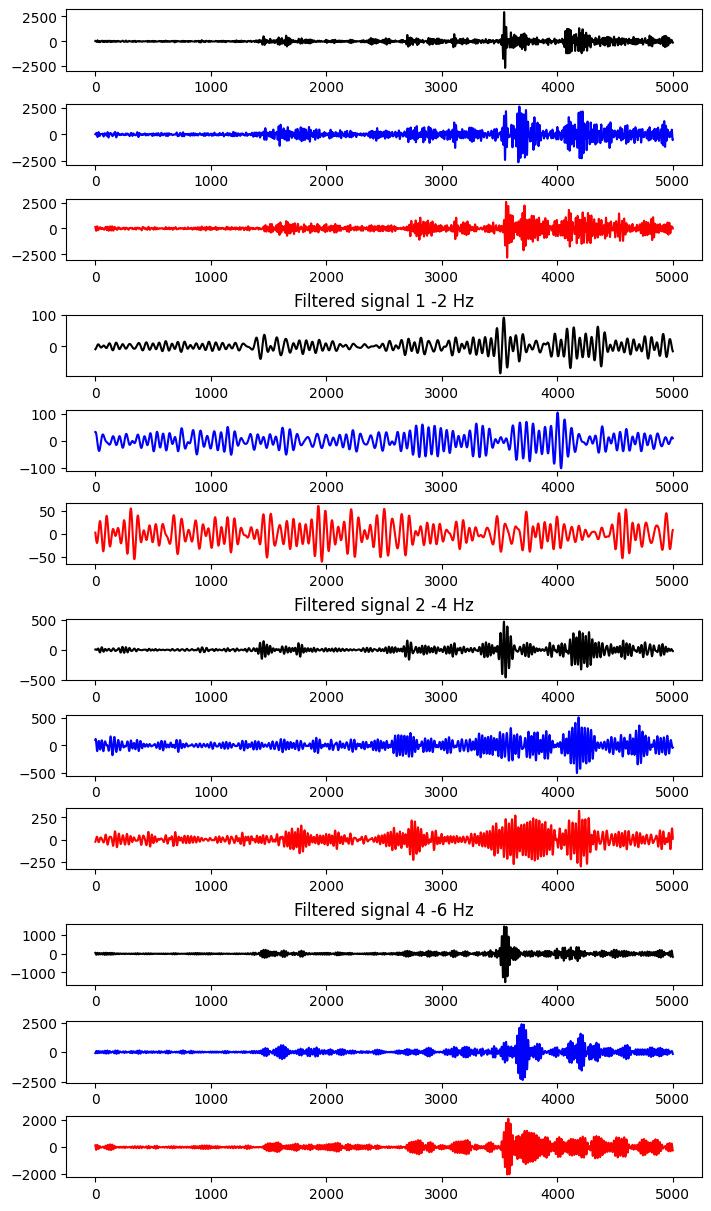

In [15]:
%matplotlib inline
n = np.random.randint(X_input.shape[0])
mpl.rcParams['figure.figsize'] = (7,12)
fig,ax = plt.subplots(12,1,layout='constrained')
#plt.figure(figsize=(10,2))
ax[0].plot(X_input[n,:,0],color='k')
# ax[0].plot(Y_target[n,:,0])
# ax[0].plot(Y_target[n,:,1])
# ax[0].plot(Y_target[n,:,2])
ax[1].plot(X_input[n,:,1],color='blue')
ax[2].plot(X_input[n,:,2],color='red')
ax[3].set_title('Filtered signal 1 -2 Hz')
ax[3].plot(X_input_filt[n,:,0,0],color='k')
ax[4].plot(X_input_filt[n,:,1,0],color='blue')
ax[5].plot(X_input_filt[n,:,2,0],color='red')
ax[6].set_title('Filtered signal 2 -4 Hz')
ax[6].plot(X_input_filt[n,:,0,1],color='k')
ax[7].plot(X_input_filt[n,:,1,1],color='blue')
ax[8].plot(X_input_filt[n,:,2,1],color='red')
ax[9].set_title('Filtered signal 4 -6 Hz')
ax[9].plot(X_input_filt[n,:,0,2],color='k')
ax[10].plot(X_input_filt[n,:,1,2],color='blue')
ax[11].plot(X_input_filt[n,:,2,2],color='red')

### Feature Engineering: X input normalization, Amplitude spectra, phase, theta computaion

In [16]:
X_input_norm = nimp.normalization(X_input)

## Amplitude feature extraction

In [ ]:
# n = 1460#np.random.randint(1705)
# mpl.rcParams['figure.figsize'] = (10,12)
# fig,ax = plt.subplots(6,1,layout='constrained')
# ax[0].plot(Time[n,:],X_input[n,:,0],label='signal')
# ax[0].set_title(f'Signal # {n}',fontsize=10)
# #plt.plot(Time[n,:],Nrg[n,:],label='Nrg')
# ax[1].plot(Time[n,:],Abs_H[n,:,0],alpha=0.5,color = 'black',label='AS V')
# ax[1].set_title('Analytic signal of V component',fontsize=10)
# ax[1].legend()
# ax[2].plot(Time[n,:],Abs_H[n,:,1],alpha=0.5,color = 'blue',label='AS N')
# ax[2].set_title('Analytic signal of N component',fontsize=10)
# ax[2].legend()
# ax[3].plot(Time[n,:],Abs_H[n,:,2],alpha=0.5,color = 'red',label='AS E')
# ax[3].set_title('Analytic signal of E component',fontsize=10)
# ax[3].legend()
# ax[4].plot(Time[n,:],Nrg[n,:],alpha=0.5,color = 'green',label='Amplitude')
# ax[4].set_title(r'Amplitude of signal: $\sqrt{N^2 + E^2 + V^2}$',fontsize=10)
# ax[4].legend()
# ax[5].plot(Time[n,:],Amp_H[n,:],alpha=0.5,color = 'magenta',label='Amp AS')
# ax[5].plot(Time[n,:],Nrg[n,:],alpha=0.5,color = 'green',label='Amplitude')
# ax[5].set_title(r'Amplitude of analytic signal: $\sqrt{H_N^2 + H_E^2 + H_V^2}$',fontsize=10)
# ax[5].legend()

## Amplitude for filtered signals between 1-2, 2-4, 4-6 Hz

In [15]:
aux = 3
for k in range(3):
    for i in range(X_input_feature.shape[0]):
        X_input_feature[i,:,aux] = np.sqrt(np.abs(X_input_filt[i,:,0,k])**2 + np.abs(X_input_filt[i,:,1,k])**2 + np.abs(X_input_filt[i,:,2,k])**2)
    aux += 1

Text(0.5, 0, 'Time [s]')

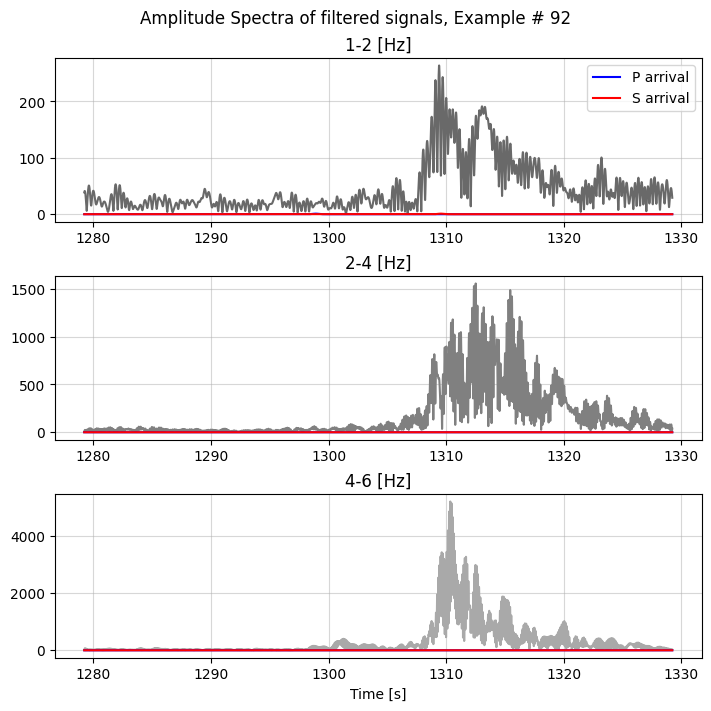

In [18]:
n = 92#np.random.randint(X_input.shape[0])
fig,ax = plt.subplots(3,1,layout='constrained',figsize=(7,7))
plt.suptitle(f'Amplitude Spectra of filtered signals, Example # {n}')
#plt.ylabel('Normalized Amplitude')
ax[0].plot(Time[n,:],X_input_feature[n,:,3],c='dimgrey')
ax[0].plot(Time[n,:],Y_target[n,:,1],c = 'blue',label = 'P arrival')
ax[0].plot(Time[n,:],Y_target[n,:,2],c = 'red',label='S arrival')
ax[0].set_title('1-2 [Hz]')
ax[0].grid(alpha=0.5)
ax[0].legend()

ax[1].plot(Time[n,:],X_input_feature[n,:,4],c='gray')
ax[1].plot(Time[n,:],Y_target[n,:,1],c = 'blue')
ax[1].plot(Time[n,:],Y_target[n,:,2],c = 'red')
ax[1].set_title('2-4 [Hz]')
ax[1].grid(alpha=0.5)

ax[2].plot(Time[n,:],X_input_feature[n,:,5],c='darkgray')
ax[2].plot(Time[n,:],Y_target[n,:,1],c = 'blue')
ax[2].plot(Time[n,:],Y_target[n,:,2],c = 'red')
ax[2].set_title('4-6 [Hz]')
ax[2].grid(alpha=0.5)
ax[2].set_xlabel('Time [s]')

#fig.savefig('Amplitude Spectra feature.png',dpi=300,bbox_inches='tight',pad_inches=0.05,transparent=True)

In [16]:
def ftan(signal,freq_range,samp_rate,Time):
    
    N = np.shape(signal)[0]
    T = 1.0/samp_rate
    b_width = 1.0            # Gauss filter band width
    
    h_sig = hilbert(signal)
    fh_sig = np.fft.fft(h_sig)/(len(h_sig)**0.5)

    freq = np.fft.fftfreq(len(h_sig), d=(1/samp_rate))
    freq_rad = freq*2*np.pi
    
    ftan_freq = np.arange(freq_range[0],freq_range[1],0.05)
    time = np.linspace(0,signal.shape[0]/samp_rate,signal.shape[0])

    ftan_data = np.zeros((signal.shape[0],ftan_freq.shape[0]),dtype=complex)
    
    for i in range(ftan_freq.shape[0]):
        wi = 2*np.pi*ftan_freq[i]
        b_width_wi = 2*np.pi*b_width
        gauss_freq = np.zeros((len(freq_rad)),dtype=complex)
        
        for j in range(freq_rad.shape[0]):
            gauss_freq[j] = (1/(((2*np.pi)**0.5)*b_width_wi))*np.exp(-1*((freq_rad[j] - wi)**2)/(2*(b_width_wi**2)))
       
        # Ftan values for each central freq
        ftan = gauss_freq * fh_sig
        ftan_data[:,i] = np.fft.ifft(ftan)*(signal.shape[0]**0.5)

    y_grid, x_grid = np.meshgrid(ftan_freq,Time)
    
    return freq,time,fh_sig,y_grid,x_grid,ftan_data

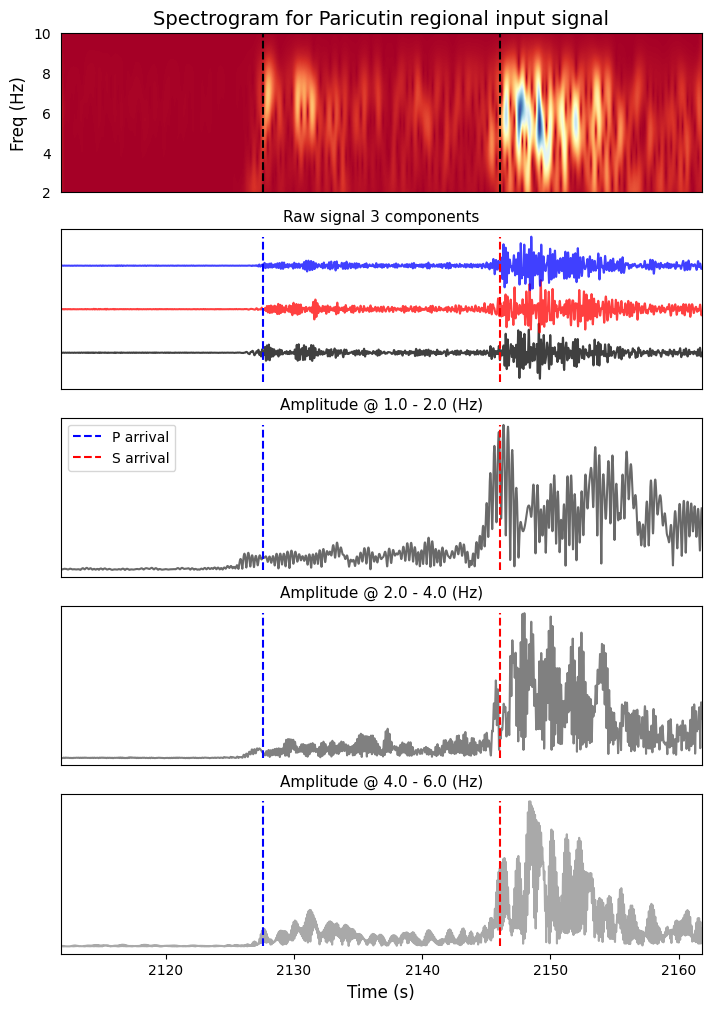

In [65]:
# testing ftan
n = 16  #np.random.randint(1900)
samp_rate = 100.0 #[Hz]
f_ran = [[1.0,12.0]]#
f_range = [[1.0,2.0],[2.0,4.0],[4.0,6.0]]
tp = Time[n,np.where(Y_target[n,:,1] == 1.0)[0][0]]
ts = Time[n,np.where(Y_target[n,:,2] == 1.0)[0][0]]
# For vlines

#ini = int(tini[n]*fsamp_orig) ; fin = int((tfin[n] + 10)*fsamp_orig)

for f in f_ran:
    freq,t, F_x,yg,xg,ftan_data = ftan(X_input_feature[n,:,0],f,samp_rate,Time[n,:])
    
fig,ax = plt.subplots(5,1,layout='constrained',figsize=(7,10))
col_mesh = ax[0].pcolormesh(xg, yg, np.absolute(ftan_data), cmap='RdYlBu')
ax[0].vlines((tp,ts),2,10,colors=('k','k'),linestyle='--')
ax[0].set_title('Spectrogram for Paricutin regional input signal',fontsize=14)
#ax[0].set_xlabel('Time [s]',fontsize=12)
ax[0].set_ylabel('Freq (Hz)',fontsize=12)
ax[0].set_ylim(2,10)
ax[0].tick_params(left = False, right = False , labelleft = True ,
                    labelbottom = False, bottom = False, labeltop = False)

ax[1].plot(Time[n,:],X_input[n,:,0] ,c='k',alpha=0.75)
ax[1].plot(Time[n,:],X_input[n,:,1]+ 1.5,c='r',alpha=0.75)
ax[1].plot(Time[n,:],X_input[n,:,2]+ 3,c='b',alpha=0.75)
# ax[1].plot(Time[n,:],Y_target[n,:,1]*max(X_input_feature[n,:,2]),c = 'blue',alpha=0.5,label='P arrival')
# ax[1].plot(Time[n,:],Y_target[n,:,2]*max(X_input_feature[n,:,2]),c = 'red',alpha=0.5,label='S arrival')
ax[1].vlines((tp,ts),-1,4,colors=('b','r'),linestyle='--')
#ax[1].set_ylabel('Amplitude',fontsize=12)
#ax[1].set_xlabel('Time [s]')
ax[1].set_title('Raw signal 3 components',fontsize=11)
ax[1].set_xlim(Time[n,0],Time[n,-1])
ax[1].tick_params(left = False, right = False , labelleft = False ,
                    labelbottom = False, bottom = False, labeltop = False)
#ax[1].legend()

ax[2].plot(Time[n,:],X_input_feature[n,:,3],c='dimgrey',alpha=1)
# ax[2].plot(Time[n,:],Y_target[n,:,1]*max(X_input_feature[n,:,3]),c = 'blue',alpha=0.5)
# ax[2].plot(Time[n,:],Y_target[n,:,2]*max(X_input_feature[n,:,3]),c = 'red',alpha=0.5)
#ax[2].vlines((tp,ts),min(X_input_feature[n,:,3]),max(X_input_feature[n,:,3]),colors=('b','r'),linestyle='--')
ax[2].vlines(tp,min(X_input_feature[n,:,3]),max(X_input_feature[n,:,3]),color='b',linestyle='--',label='P arrival')
ax[2].vlines(ts,min(X_input_feature[n,:,3]),max(X_input_feature[n,:,3]),color='r',linestyle='--',label='S arrival')
#ax[2].set_ylabel('Amplitude',fontsize=12)
#ax[2].set_xlabel('Time [s]')
ax[2].set_title(f'Amplitude @ {f_range[0][0]} - {f_range[0][1] } (Hz)',fontsize=11)
ax[2].set_xlim(Time[n,0],Time[n,-1])
ax[2].tick_params(left = False, right = False , labelleft = False ,
                    labelbottom = False, bottom = False, labeltop = False)
ax[2].legend()

ax[3].plot(Time[n,:],X_input_feature[n,:,4],c='gray',alpha=1)
# ax[3].plot(Time[n,:],Y_target[n,:,1]*max(X_input_feature[n,:,4]),c = 'blue',alpha=0.5)
# ax[3].plot(Time[n,:],Y_target[n,:,2]*max(X_input_feature[n,:,4]),c = 'red',alpha=0.5)
ax[3].vlines((tp,ts),min(X_input_feature[n,:,4]),max(X_input_feature[n,:,4]),colors=('b','r'),linestyle='--')
#ax[3].set_ylabel('Amplitude',fontsize=12)
#ax[3].set_xlabel('Time [s]')
ax[3].set_title(f'Amplitude @ {f_range[1][0]} - {f_range[1][1] } (Hz)',fontsize=11)
ax[3].set_xlim(Time[n,0],Time[n,-1])
ax[3].tick_params(left = False, right = False , labelleft = False ,
                    labelbottom = False, bottom = False, labeltop = False)

ax[4].plot(Time[n,:],X_input_feature[n,:,5],c='darkgray',alpha=1)
# ax[4].plot(Time[n,:],Y_target[n,:,1]*max(X_input_feature[n,:,5]),c = 'blue',alpha=0.5)
# ax[4].plot(Time[n,:],Y_target[n,:,2]*max(X_input_feature[n,:,5]),c = 'red',alpha=0.5)
ax[4].vlines((tp,ts),min(X_input_feature[n,:,5]),max(X_input_feature[n,:,5]),colors=('b','r'),linestyle='--')
#ax[4].set_ylabel('Amplitude',fontsize=12)
#ax[4].set_xlabel('Time [s]')
ax[4].set_title(f'Amplitude @ {f_range[2][0]} - {f_range[2][1] } (Hz)',fontsize=11)
ax[4].set_xlim(Time[n,0],Time[n,-1])
ax[4].set_xlabel('Time (s)',fontsize=12)
ax[4].tick_params(left = False, right = False , labelleft = False ,
                    labelbottom = True, bottom = True, labeltop = False)

# ax[5].set_title(fr'Incidence angle $\phi(t)$',fontsize=11)
# ax[5].scatter(Time[n,:],X_input_feature[n,:,6],s = 0.3,marker='.',color='magenta')
# ax[5].plot(Time[n,:],X_input_feature[n,:,6],linewidth=0.1)
# ax[5].set_xlabel('Time [s]',fontsize=12)
# ax[5].set_ylabel('rad',fontsize=12)
# ax[5].set_xlim(Time[n,0],Time[n,-1])

fig.savefig('Spectrogram_inputsignal_features_2025.png',dpi=300, bbox_inches='tight',pad_inches=0.05)

In [42]:
tp

1576

### Smooth sum of amplitudes

In [16]:
sum_amps = X_input_feature[:,:,5] + X_input_feature[:,:,6] + X_input_feature[:,:,7]

IndexError: index 7 is out of bounds for axis 2 with size 7

In [ ]:
sum_amps.shape

In [ ]:
n = np.random.randint(X_input_feature.shape[0])
smooth_sum = smooth(sum_amps[n,:],301)

In [ ]:
plt.figure(figsize=(7,2))
plt.plot(Time[n,:],sum_amps[n,:]/max(sum_amps[n,:]),c='black',linewidth=0.5)
plt.plot(Time[n,:],smooth_sum/max(smooth_sum))
plt.plot(Time[n,:],Y_target[n,:,1],c='blue',alpha=0.5,label='P')
plt.plot(Time[n,:],Y_target[n,:,2],c='red',alpha=0.5,label='S')

## Incidence angle

### Phi and theta angles computation

In [17]:
#### Filiing X input feature array with phi and theta

smooth_EW = np.zeros((X_input_feature.shape[0],X_input_feature.shape[1]))
smooth_NS = np.zeros((X_input_feature.shape[0],X_input_feature.shape[1]))
smooth_V  = np.zeros((X_input_feature.shape[0],X_input_feature.shape[1]))

g2r = 180/np.pi
for i in range(X_input.shape[0]):

    smooth_EW[i,:] = nimp.smooth(X_input_feature[i,:,2],101)
    smooth_NS[i,:] = nimp.smooth(X_input_feature[i,:,1],101)
    smooth_V[i,:]  = nimp.smooth(X_input_feature[i,:,0],101)

    X_input_feature[i,:,6] = np.arctan(smooth_EW[i,:]/smooth_NS[i,:]) # theta(t)
    X_input_feature[i,:,7] = np.arctan(np.sqrt((smooth_EW[i,:])**2 + (smooth_NS[i,:]**2))/smooth_V[i,:]) # phi(t)

Text(0.5, 0, 'Time [s]')

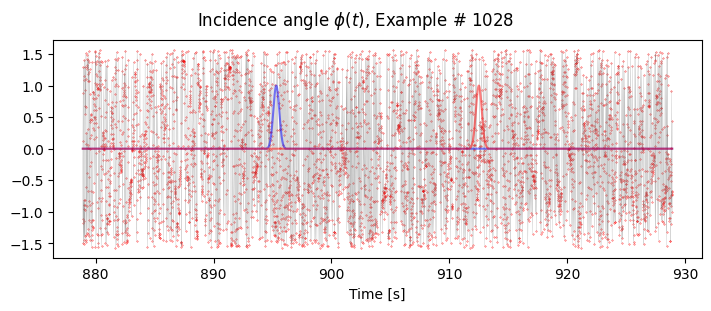

In [18]:
n = np.random.randint(X_input_feature.shape[0])

mpl.rcParams['figure.figsize'] = (7,3)
fig,ax = plt.subplots(1,1,layout='constrained')
plt.suptitle(fr'Incidence angle $\phi(t)$, Example # {n}')
ax.scatter(Time[n,:],X_input_feature[n,:,6],s = 0.3,marker='.',color='red')
ax.plot(Time[n,:],X_input_feature[n,:,6],linewidth=0.1,color='dimgrey')
#pl0.plot(Time[n,:],Y_target[n,:,0])
ax.plot(Time[n,:],Y_target[n,:,1],c='blue',alpha=0.5,)
ax.plot(Time[n,:],Y_target[n,:,2],c='red',alpha=0.5,)
ax.set_xlabel('Time [s]')
#ax.legend()
#fig.savefig('Angles feature.png',dpi=300,bbox_inches='tight',pad_inches=0.05,transparent=True)

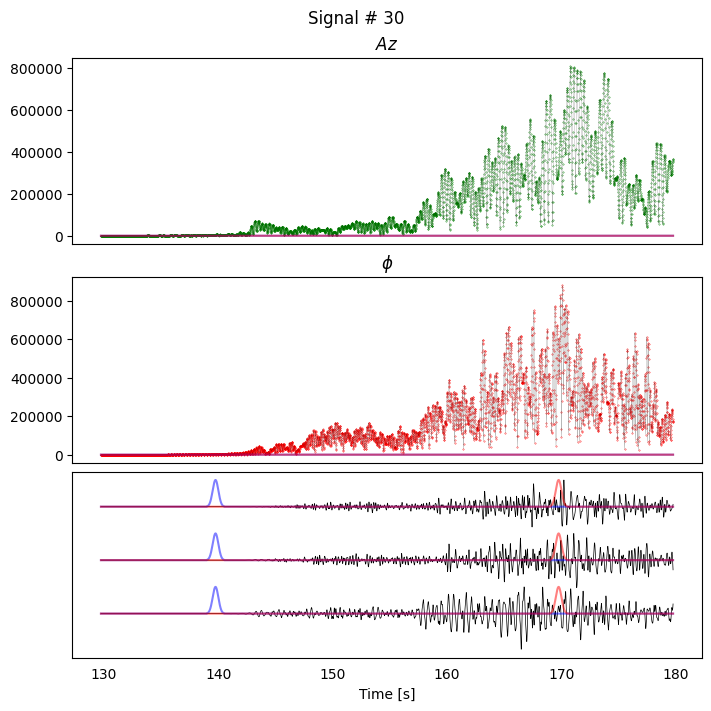

In [38]:
n = 30#np.random.randint(X_input_norm.shape[0]) #1191
fig,ax = plt.subplots(3,1,layout='constrained',figsize=(7,7))
plt.suptitle(f'Signal # {n}')
ax[0].set_title(fr'$Az$')##{n}
ax[0].scatter(Time[n,:],X_input_feature[n,:,3],s = 0.3,marker='.',color='green')
ax[0].plot(Time[n,:],X_input_feature[n,:,3],c='black',linewidth=0.1)
#ax[0].plot(Time[n,:],Y_target[n,:,0])
ax[0].plot(Time[n,:],Y_target[n,:,1],c='blue',alpha=0.5)
ax[0].plot(Time[n,:],Y_target[n,:,2],c='red',alpha=0.5)
ax[0].tick_params(left = True, right = False , labelleft = True ,
                    labelbottom = False, bottom = False, labeltop = False)

ax[1].set_title(fr'$\phi$')#{n}
ax[1].scatter(Time[n,:],X_input_feature[n,:,4],s = 0.3,marker='.',color='red')
ax[1].plot(Time[n,:],X_input_feature[n,:,4],c='black',linewidth=0.1)
#ax[1].plot(Time[n,:],Y_target[n,:,0])
ax[1].plot(Time[n,:],Y_target[n,:,1],c='blue',alpha=0.5)
ax[1].plot(Time[n,:],Y_target[n,:,2],c='red',alpha=0.5)
ax[1].tick_params(left = True, right = False , labelleft = True ,
                    labelbottom = False, bottom = False, labeltop = False)

ax[2].plot(Time[n,:],X_input_norm[n,:,0],c='black',linewidth=0.5)
ax[2].plot(Time[n,:],X_input_norm[n,:,1]+2,c='black',linewidth=0.5)
ax[2].plot(Time[n,:],X_input_norm[n,:,2]+4,c='black',linewidth=0.5)
ax[2].plot(Time[n,:],Y_target[n,:,1],c='blue',alpha=0.5)
ax[2].plot(Time[n,:],Y_target[n,:,2],c='red',alpha=0.5)
ax[2].plot(Time[n,:],Y_target[n,:,1]+2,c='blue',alpha=0.5)
ax[2].plot(Time[n,:],Y_target[n,:,2]+2,c='red',alpha=0.5)
ax[2].plot(Time[n,:],Y_target[n,:,1]+4,c='blue',alpha=0.5)
ax[2].plot(Time[n,:],Y_target[n,:,2]+4,c='red',alpha=0.5)
ax[2].set_xlabel('Time [s]')
ax[2].tick_params(left = False, right = False , labelleft = False,
                    labelbottom = True, bottom = False, labeltop = False)

#fig.savefig('Angles feature.png',dpi=300,bbox_inches='tight',pad_inches=0.05,transparent=True)

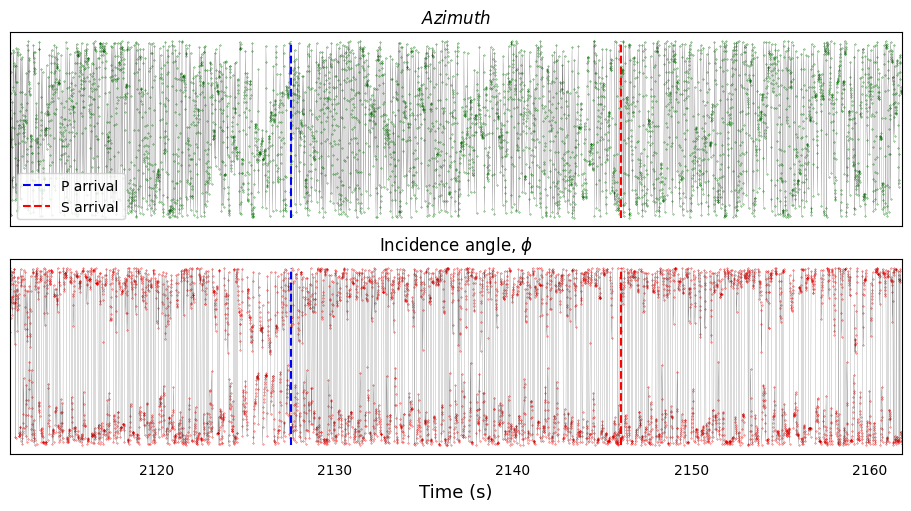

In [19]:
n = 16#92# np.random.randint(X_input_feature.shape[0]) #1191

tp = Time[n,np.where(Y_target[n,:,1] == 1.0)[0][0]]
ts = Time[n,np.where(Y_target[n,:,2] == 1.0)[0][0]]

fig,ax = plt.subplots(2,1,layout='constrained',figsize=(9,5))

ax[0].set_title(fr'$Azimuth$')##{n}
ax[0].scatter(Time[n,:],X_input_feature[n,:,6],s = 0.3,marker='.',color='green')
ax[0].plot(Time[n,:],X_input_feature[n,:,6],c='black',linewidth=0.1)
#ax[0].plot(Time[n,:],Y_target[n,:,0])
# ax[0].plot(Time[n,:],Y_target[n,:,1]*1.5,c='blue',alpha=0.5)
# ax[0].plot(Time[n,:],Y_target[n,:,2]*1.5,c='red',alpha=0.5)
ax[0].vlines(tp,min(X_input_feature[n,:,6]),max(X_input_feature[n,:,6]),color='b',linestyle='--',label='P arrival')
ax[0].vlines(ts,min(X_input_feature[n,:,6]),max(X_input_feature[n,:,6]),color='r',linestyle='--',label='S arrival')
ax[0].tick_params(left = False, right = False , labelleft = False ,
                    labelbottom = False, bottom = False, labeltop = False)
ax[0].set_xlim(Time[n,0],Time[n,-1])
ax[0].legend()

ax[1].set_title(fr'Incidence angle, $\phi$')#{n}
ax[1].scatter(Time[n,:],X_input_feature[n,:,7],s = 0.3,marker='.',color='red')
ax[1].plot(Time[n,:],X_input_feature[n,:,7],c='black',linewidth=0.1)
#ax[1].plot(Time[n,:],Y_target[n,:,0])
# ax[1].plot(Time[n,:],Y_target[n,:,1]*1.5,c='blue',alpha=0.5)
# ax[1].plot(Time[n,:],Y_target[n,:,2]*1.5,c='red',alpha=0.5)
ax[1].vlines(tp,min(X_input_feature[n,:,7]),max(X_input_feature[n,:,7]),color='b',linestyle='--',label='P arrival')
ax[1].vlines(ts,min(X_input_feature[n,:,7]),max(X_input_feature[n,:,7]),color='r',linestyle='--',label='S arrival')
ax[1].set_xlabel('Time (s)',fontsize=13)
ax[1].tick_params(left = False, right = False , labelleft = False ,
                    labelbottom = True, bottom = False, labeltop = False)
ax[1].set_xlim(Time[n,0],Time[n,-1])

fig.savefig('Angles feature 2025.png',dpi=300,bbox_inches='tight',pad_inches=0.05,transparent=False)

In [ ]:
# ## Filling the X input feature array
# n = np.random.randint(1900)
# g2r = 180/np.pi
# for i in range(X_input.shape[0]):
#     X_input_feature[i,:,3] = np.arctan(smooth(X_input[i,:,2],100)/X_input[i,:,1]) # theta(t)
#     X_input_feature[i,:,4] = np.arctan(np.sqrt((X_input[i,:,2])**2 + (X_input[i,:,1]**2)) / X_input[i,:,0]) # phi(t)

In [ ]:
opc = False
if opc:
    nsig = X_input_norm.shape[0]
    mpl.rcParams['figure.figsize'] = (7,3*20)
    #fig,ax = plt.subplots(10,1,layout='constrained')
    aux = 0
    ini = 100
    fin = X_input_feature.shape[0]
    # list that includes initial and final values of plots
    inter = []
    nlist = int(fin/20)

    for i in range(ini,fin,20):
        inter.append([i,i+20])

    aux = 5
    for j in inter:#[58:59]
        ini = j[0]
        fin = j[1]
        aux += 1 
        print(j,ini,fin,aux)
        
        fig,ax = plt.subplots(20,1,layout='constrained')
        for idx,i in enumerate(range(ini,fin)):
            #print(aux)
            plt.suptitle(f'Azimuth: {ini} to {fin}')
            ax[idx].set_title(f'Signal # {i}',fontsize=8)
            ax[idx].scatter(Time[i,:],X_input_feature[i,:,3],s = 0.3,marker='.',color='green')
            ax[idx].plot(Time[i,:],X_input_feature[i,:,3],c='black',linewidth=0.1)
            ax[idx].plot(Time[i,:],Y_target[i,:,1],color='blue',alpha=0.5,label = 'P')
            ax[idx].plot(Time[i,:],Y_target[i,:,2],color='red',alpha=0.5,label = 'S')
            ax[idx].legend()
            fig.savefig(f'Azimuth_feature/Azimuth_{aux}.png',bbox_inches='tight',pad_inches=0.05,dpi=100)
            plt.close(fig)

## Normalization of the input dataset with the feature selection:
* Which normalization process is the better for this case?

In [20]:
# Normalization
X_input  = nimp.normalization(X_input_feature)
X_input.shape

(1394, 5000, 7)

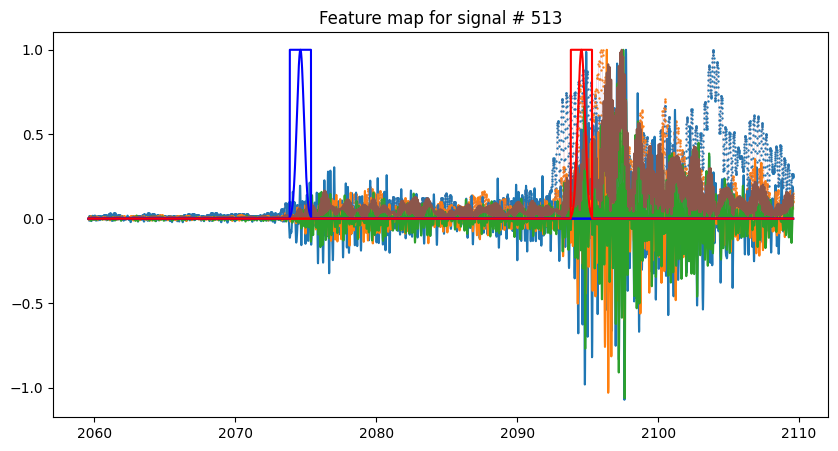

In [21]:
# Feature Engineering map
n = np.random.randint(X_input.shape[0])

plt.figure(figsize=(10,5))
plt.title(f'Feature map for signal # {n}')
plt.plot(Time[n,:],X_input[n,:,0])
plt.plot(Time[n,:],X_input[n,:,1])
plt.plot(Time[n,:],X_input[n,:,2])
plt.scatter(Time[n,:],X_input[n,:,3],s=0.5)
plt.plot(Time[n,:],X_input_feature[n,:,3],linewidth=0.07)
plt.scatter(Time[n,:],X_input[n,:,4],s=0.5)
plt.plot(Time[n,:],X_input_feature[n,:,4],linewidth=0.07)
plt.plot(Time[n,:],X_input[n,:,5])
#plt.plot(Time[n,:],X_input[n,:,6])
#plt.plot(Time[1915,:],Y_target[1915,:,0],color='black')
plt.plot(Time[n,:],Y_target[n,:,1],color='blue')
plt.plot(Time[n,:],Y_target[n,:,2],color='red')

plt.plot(Time[n,:],Y_target_cl[n,:,0],color='blue')
plt.plot(Time[n,:],Y_target_cl[n,:,1],color='red')

## Splitting dataset into training and testing sets

### Extracting train and test datasets in batches

In [91]:
# Input tensors without dimension expansion for 1D layers intended usage 
x_input = copy.copy(X_input)
y_target = copy.copy(Y_target_cl)
print(f'Final X input shape: {x_input.shape} \nFinal y target shape{y_target.shape}')

Final X input shape: (1394, 5000, 7) 
Final y target shape(1394, 5000, 2)


## Manual train and test datasets splitting with random seed for reproducibility matters

In [92]:
train_per = 0.75
test_per = 1.0 - train_per

Xtrain, ytrain, t_train, Xtest, ytest, t_test = nimp.manual_train_test_split_multiclass(train_per,
                                                                                        test_per,x_input,y_target,Time)

Ninput:1394,Ntest:5000, Ntrain:1045, Ntest:348
Ncomp:7, Nclass:1
1045 348
(1045, 5000, 7) (348, 5000, 7) (1045, 5000, 2) (348, 5000, 2) (1045, 5000) (348, 5000)


## Neural Network model definition
Unet 1-D, variable depth, based on image segmentation conceptualization

## 1D UNet adaptation: variable depth (HAGDAVS implementation)

In [94]:
# Neural network libraries
import tensorflow as tf
import tensorflow_io as tfio
from tensorflow import keras
from tensorflow.keras import layers
#from tensorflow.keras.layers.experimental import preprocessing
from tensorflow.data import AUTOTUNE
#from tensorflow.keras.callbacks import TensorBoa
from tensorflow.keras.layers import BatchNormalization, ReLU, Dropout, Flatten, MaxPool1D
from tensorflow.keras.layers import Conv1D, Conv1DTranspose, Dense, TimeDistributed

from tensorflow.keras.regularizers import L1,L2

## Manual splitted datasets training

In [23]:
tf.__version__

'2.12.0'

In [ ]:
# t = tf.constant([[[1, 1, 1], [2, 2, 2]],
#                  [[3, 3, 3], [4, 4, 4]],
#                  [[5, 5, 5], [6, 6, 6]]])
# print(t)
# tf.slice(t, [1, 0, 0], [1, 1, 3])  # [[[3, 3, 3]]]
# tf.slice(t, [1, 0, 0], [1, 2, 3])  # [[[3, 3, 3],
#                                    #   [4, 4, 4]]]
# #tf.slice(t, [0, 0, 0], [-1, 2, -1])  # [[[3, 3, 3]],
#                                    #  [[5, 5, 5]]]
# print(tf.slice(t, [0, 0, 0], [-1, 2, -1]) )
# print(tf.slice(t, [0, 0, 0], [0, 2,0]) )
# print(tf.slice(t, [0, 0, 0], [-1, 2, 1]) )

In [21]:
# ## UNet: Adapted to latest tensorflow.keras version

# def crop_and_concat(net1, net2): #(Funciona para x_input:(5000,3))
#     """
#       the size(net1) <= size(net2)
#     """
#     #print(type(net1),type(net2))
#     #
#     print(net1.shape,net2.shape)
#     ## dynamic shape
#     #chn1 = net1.get_shape().as_list()[-1]
#     #chn2 = net2.get_shape().as_list()[-1]
#     #chn1 = net1.shape.as_list()[-1]
#     #chn2 = net2.shape.as_list()[-1]
#     chn1 = list(net1.shape)[-1]
#     chn2 = list(net2.shape)[-1]
#     #print(f'chn1: {chn1}, chn2: {chn2}')
    
#     #net1_shape = tf.shape(net1)
#     #net2_shape = tf.shape(net2)
#     net1_shape = net1.shape    #tf.TensorShape(net1)
#     net2_shape = net2.shape    #tf.TensorShape(net2)
    
#     #print(f'chn1: {chn1}, chn2: {chn2}')
#     print(f'net1_shape: {net1_shape}')
#     print(f'net2_shape: {net2_shape}')
    
#     offsets = [0, (net2_shape[1] - net1_shape[1]) // 2, 0]
#     #size = [-1, net1_shape[1], -1]
#     size = [net1_shape[-1], net1_shape[1], net1_shape[-1]]
    
#     #print(f'offsets: {offsets}')
#     #print(f'size: {size}')
    
#     #print('\n type net2',type(net2))
    
#     print('before slice net2 shape:',net2_shape)
#     #net2_resize = tf.slice(net2, offsets, size)
#     net2_resize = tf.keras.ops.slice(net2, offsets, size)
#     print('net2 slice: ',net2_resize)
#     #net2_resize = Lay_slice()(x)

#     #out = tf.concat([net1, net2_resize], 2)
#     print('before concatenate: ',net1.shape,net2_resize.shape)
#     out = tf.keras.ops.concatenate([net1, net2_resize], 0)
#     print(out.shape)
#     #out.set_shape([None,None, chn1+chn2])
    
# #     tf.keras.ops.reshape(out,[None,None,chn1+chn2])
# #     print(out.shape)

#     return out 

# def double_conv_block(x, n_filters):

#     # Conv2D then ReLU activation
#     x = layers.Conv1D(n_filters, 3, padding = "same", kernel_initializer = "he_normal")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.Activation("relu")(x)
#     # Conv2D then ReLU activation
#     x = layers.Conv1D(n_filters, 3, padding = "same", kernel_initializer = "he_normal")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.Activation("relu")(x)
#     # Conv2D then ReLU activation
#     x = layers.Conv1D(n_filters, 3, padding = "same", kernel_initializer = "he_normal")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.Activation("relu")(x)
#     # dropout
#     x = layers.Dropout(0.2)(x)

#     return x

# def downsample_block(x, n_filters):
#     f = double_conv_block(x, n_filters)
#     p = layers.MaxPool1D(2)(f)
#     p = layers.Dropout(0.2)(p)

#     return f, p

# def upsample_block(x, conv_features, n_filters):
#     # upsample
#     x = layers.Conv1DTranspose(n_filters, 3, 2, padding="same")(x)
#     # concatenate
#     #x = layers.concatenate([x, conv_features],axis=1)
#     #x = layers.concatenate([x, conv_features],axis=-1)
#     #x = crop_and_concat(x, conv_features)
#     #x = crop_and_concat(conv_features,x)
#     x = crop_and_concat(x,conv_features)
#     # dropout
#     x = layers.Dropout(0.2)(x)
#     # Conv2D twice with ReLU activation
#     x = double_conv_block(x, n_filters)

#     return x

# def build_unet_model(x_input): # Main builder!!

#     # inputs
#     #inputs = layers.Input(shape=(5000,1,3))
#     input_shape = tf.TensorShape(x_input[0,...].shape)
#     inputs = layers.Input(shape=input_shape)

#     # encoder: contracting path - downsample
#     # 1 - downsample
#     f1, p1 = downsample_block(inputs, 64)
#     # 2 - downsample
#     f2, p2 = downsample_block(p1, 128)
#     # 3 - downsample
#     f3, p3 = downsample_block(p2, 256)
#     # 4 - downsample
#     f4, p4 = downsample_block(p3, 512)

#     # 5 - bottleneck
#     bottleneck = double_conv_block(p4, 1024)
#     bottleneck = layers.Dropout(0.3)(bottleneck)

#     # decoder: expanding path - upsample
#     # 6 - upsample
#     u6 = upsample_block(bottleneck, f4, 512)
#     # 7 - upsample
#     u7 = upsample_block(u6, f3, 256)
#     # 8 - upsample
#     u8 = upsample_block(u7, f2, 128)
#     # 9 - upsample
#     u9 = upsample_block(u8, f1, 64)

#     # outputs
#     x = layers.Conv1D(2, 1, padding="same", kernel_initializer = "he_normal")(u9)
#     outputs = layers.TimeDistributed(Dense(2, activation='sigmoid', name = 'Output'))(x)
                              
#     # unet model with Keras Functional API
#     #net_model = tf.keras.Model(inputs, outputs, name="U-Net_multi")
#     unet_model = tf.keras.Model(inputs, outputs, name="U-Net_Incidence_Feat")

#     return unet_model

In [152]:
def crop_and_concat(net1, net2): #(Funciona para x_input:(5000,3))
    """
      the size(net1) <= size(net2)
    """
    ## dynamic shape

    chn1 = list(net1.shape)[-1]
    chn2 = list(net2.shape)[-1]
    net1_shape = tf.shape(net1)
    net2_shape = tf.shape(net2)

    offsets = [0, (net2_shape[1] - net1_shape[1]) // 2, 0]
    size = [-1, net1_shape[1], -1]

    net2_resize = tf.slice(net2, offsets, size)

    out = tf.concat([net1, net2_resize], 2)
    out.set_shape([None,None, chn1+chn2])

    return out 

def double_conv_block(x, n_filters, kern_size):

    # Conv2D then ReLU activation
    x = layers.Conv1D(n_filters, kernel_size = kern_size, padding = "same", kernel_initializer = "he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    # Conv2D then ReLU activation
    x = layers.Conv1D(n_filters, kernel_size = kern_size, padding = "same", kernel_initializer = "he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    # Conv2D then ReLU activation
    x = layers.Conv1D(n_filters, kernel_size = kern_size, padding = "same", kernel_initializer = "he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    # dropout
    x = layers.Dropout(0.2)(x)

    return x

def downsample_block(x, n_filters, kern_size):
    f = double_conv_block(x, n_filters,kern_size)
    p = layers.MaxPool1D(2)(f)
    p = layers.Dropout(0.2)(p)

    return f, p

def upsample_block(x, conv_features, n_filters, kern_size):
    # upsample
    x = layers.Conv1DTranspose(n_filters, kernel_size = kern_size,strides =  2, padding="same")(x)
    # concatenate
    x = crop_and_concat(x,conv_features)
    # dropout
    x = layers.Dropout(0.2)(x)
    # Conv2D twice with ReLU activation
    x = double_conv_block(x, n_filters, kern_size)

    return x

def build_unet_model(x_input): # Main builder!!
    
    kern_size = 7

    # inputs
    #inputs = layers.Input(shape=(5000,1,3))
    input_shape = tf.TensorShape(x_input[0,...].shape)
    inputs = layers.Input(shape=input_shape)

    # encoder: contracting path - downsample
    # 1 - downsample
    f1, p1 = downsample_block(inputs, 64, kern_size)
    # 2 - downsample
    f2, p2 = downsample_block(p1, 128, kern_size)
    # 3 - downsample
    f3, p3 = downsample_block(p2, 256, kern_size)
    # 4 - downsample
    f4, p4 = downsample_block(p3, 512, kern_size)

    # 5 - bottleneck
    bottleneck = double_conv_block(p4, 1024, kern_size)
    bottleneck = layers.Dropout(0.2)(bottleneck)

    # decoder: expanding path - upsample
    # 6 - upsample
    u6 = upsample_block(bottleneck, f4, 512, kern_size)
    # 7 - upsample
    u7 = upsample_block(u6, f3, 256, kern_size)
    # 8 - upsample
    u8 = upsample_block(u7, f2, 128, kern_size)
    # 9 - upsample
    u9 = upsample_block(u8, f1, 64, kern_size)

    # outputs
    x = layers.Conv1D(2, kernel_size = 1, padding="same", kernel_initializer = "he_normal")(u9)
    outputs = layers.TimeDistributed(Dense(2, activation='sigmoid', name = 'Output'))(x)
                              
    # unet model with Keras Functional API
    unet_model = tf.keras.Model(inputs, outputs, name="U-Net_Inc_Amp_Feat")

    return unet_model

### Unet with L2 regularization

In [132]:
opc = False
if opc:
    def crop_and_concat(net1, net2): #(Funciona para x_input:(5000,3))
        """
          the size(net1) <= size(net2)
        """
        ## dynamic shape

        chn1 = list(net1.shape)[-1]
        chn2 = list(net2.shape)[-1]
        net1_shape = tf.shape(net1)
        net2_shape = tf.shape(net2)

        offsets = [0, (net2_shape[1] - net1_shape[1]) // 2, 0]
        size = [-1, net1_shape[1], -1]

        net2_resize = tf.slice(net2, offsets, size)

        out = tf.concat([net1, net2_resize], 2)
        out.set_shape([None,None, chn1+chn2])

        return out 

    def double_conv_block(x, n_filters, k_reg):

        # Conv2D then ReLU activation
        x = layers.Conv1D(n_filters,3,padding="same",kernel_initializer="he_normal",kernel_regularizer=L2(k_reg))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        # Conv2D then ReLU activation
        x = layers.Conv1D(n_filters,3,padding="same",kernel_initializer="he_normal",kernel_regularizer=L2(k_reg))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        # Conv2D then ReLU activation
        x = layers.Conv1D(n_filters,3,padding="same",kernel_initializer="he_normal",kernel_regularizer=L2(k_reg))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        # dropout
        x = layers.Dropout(0.2)(x)

        return x

    def downsample_block(x, n_filters, k_reg):
        f = double_conv_block(x, n_filters, k_reg)
        p = layers.MaxPool1D(2)(f)
        p = layers.Dropout(0.2)(p)

        return f, p

    def upsample_block(x, conv_features, n_filters, k_reg):
        # upsample
        x = layers.Conv1DTranspose(n_filters, 3, 2, padding="same", kernel_regularizer = L2(k_reg))(x)
        # concatenate
        x = crop_and_concat(x,conv_features)
        # dropout
        x = layers.Dropout(0.2)(x)
        # Conv2D twice with ReLU activation
        x = double_conv_block(x, n_filters, k_reg)

        return x

    def build_unet_model_L2(x_input): # Main builder!!

        k_reg = 0.001

        # inputs
        #inputs = layers.Input(shape=(5000,1,3))
        input_shape = tf.TensorShape(x_input[0,...].shape)
        inputs = layers.Input(shape=input_shape)

        # encoder: contracting path - downsample
        # 1 - downsample
        f1, p1 = downsample_block(inputs, 64, k_reg)
        # 2 - downsample
        f2, p2 = downsample_block(p1, 128, k_reg)
        # 3 - downsample
        f3, p3 = downsample_block(p2, 256, k_reg)
        # 4 - downsample
        f4, p4 = downsample_block(p3, 512, k_reg)

        # 5 - bottleneck
        bottleneck = double_conv_block(p4, 1024, k_reg)
        bottleneck = layers.Dropout(0.3)(bottleneck)

        # decoder: expanding path - upsample
        # 6 - upsample
        u6 = upsample_block(bottleneck, f4, 512, k_reg)
        # 7 - upsample
        u7 = upsample_block(u6, f3, 256, k_reg)
        # 8 - upsample
        u8 = upsample_block(u7, f2, 128, k_reg)
        # 9 - upsample
        u9 = upsample_block(u8, f1, 64, k_reg)

        # outputs
        x = layers.Conv1D(2, 1, padding="same", kernel_initializer="he_normal",kernel_regularizer=L2(k_reg))(u9)
        outputs = layers.TimeDistributed(Dense(2, activation='sigmoid', name = 'Output'))(x)

        # unet model with Keras Functional API
        #net_model = tf.keras.Model(inputs, outputs, name="U-Net_multi")
        unet_model_L2 = tf.keras.Model(inputs, outputs, name="U-Net_Inc_Amp_Feat_L2")

        return unet_model_L2

In [153]:
# Unet Image Segmentation Convolutional Neural Network definition:
name_model = "U-Net_multi_Incidence_Amplitude_v2_1024_lr001.keras"
unet_model = build_unet_model(x_input)
unet_model.summary()
#loss = keras.losses.sparse_categorical_crossentropy()

Model: "U-Net_Inc_Amp_Feat"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 5000, 7)]    0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 5000, 64)     3200        ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 5000, 64)    256         ['conv1d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 activation (Activation)        (None, 5000, 64)     0           ['batch_normaliz

                                                                                                  
 dropout_5 (Dropout)            (None, 625, 256)     0           ['max_pooling1d_2[0][0]']        
                                                                                                  
 conv1d_9 (Conv1D)              (None, 625, 512)     918016      ['dropout_5[0][0]']              
                                                                                                  
 batch_normalization_9 (BatchNo  (None, 625, 512)    2048        ['conv1d_9[0][0]']               
 rmalization)                                                                                     
                                                                                                  
 activation_9 (Activation)      (None, 625, 512)     0           ['batch_normalization_9[0][0]']  
                                                                                                  
 conv1d_10

                                                                 ]']                              
                                                                                                  
 tf.concat (TFOpLambda)         (None, 624, 1024)    0           ['conv1d_transpose[0][0]',       
                                                                  'tf.slice[0][0]']               
                                                                                                  
 dropout_10 (Dropout)           (None, 624, 1024)    0           ['tf.concat[0][0]']              
                                                                                                  
 conv1d_15 (Conv1D)             (None, 624, 512)     3670528     ['dropout_10[0][0]']             
                                                                                                  
 batch_normalization_15 (BatchN  (None, 624, 512)    2048        ['conv1d_15[0][0]']              
 ormalizat

 ormalization)                                                                                    
                                                                                                  
 activation_20 (Activation)     (None, 1248, 256)    0           ['batch_normalization_20[0][0]'] 
                                                                                                  
 dropout_13 (Dropout)           (None, 1248, 256)    0           ['activation_20[0][0]']          
                                                                                                  
 conv1d_transpose_2 (Conv1DTran  (None, 2496, 128)   229504      ['dropout_13[0][0]']             
 spose)                                                                                           
                                                                                                  
 tf.compat.v1.shape_5 (TFOpLamb  (3,)                0           ['dropout_2[0][0]']              
 da)      

                                                                 0]']                             
                                                                                                  
 tf.compat.v1.floor_div_3 (TFOp  ()                  0           ['tf.math.subtract_3[0][0]']     
 Lambda)                                                                                          
                                                                                                  
 tf.__operators__.getitem_11 (S  ()                  0           ['tf.compat.v1.shape_6[0][0]']   
 licingOpLambda)                                                                                  
                                                                                                  
 tf.slice_3 (TFOpLambda)        (None, 4992, 64)     0           ['dropout[0][0]',                
                                                                  'tf.compat.v1.floor_div_3[0][0]'
          

In [97]:
# # Unet Image Segmentation Convolutional Neural Network definition: with regularization L2
# name_model = "U-Net_multi_Incidence_Amplitude_L2_1024.keras"
# unet_model_L2 = build_unet_model_L2(x_input)
# unet_model_L2.summary()
# #loss = keras.losses.sparse_categorical_crossentropy()

Model: "U-Net_Inc_Amp_Feat_L2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 5000, 7)]    0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 5000, 64)     1408        ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 5000, 64)    256         ['conv1d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 activation (Activation)        (None, 5000, 64)     0           ['batch_norma

                                                                                                  
 dropout_5 (Dropout)            (None, 625, 256)     0           ['max_pooling1d_2[0][0]']        
                                                                                                  
 conv1d_9 (Conv1D)              (None, 625, 512)     393728      ['dropout_5[0][0]']              
                                                                                                  
 batch_normalization_9 (BatchNo  (None, 625, 512)    2048        ['conv1d_9[0][0]']               
 rmalization)                                                                                     
                                                                                                  
 activation_9 (Activation)      (None, 625, 512)     0           ['batch_normalization_9[0][0]']  
                                                                                                  
 conv1d_10

                                                                 ]']                              
                                                                                                  
 tf.concat (TFOpLambda)         (None, 624, 1024)    0           ['conv1d_transpose[0][0]',       
                                                                  'tf.slice[0][0]']               
                                                                                                  
 dropout_10 (Dropout)           (None, 624, 1024)    0           ['tf.concat[0][0]']              
                                                                                                  
 conv1d_15 (Conv1D)             (None, 624, 512)     1573376     ['dropout_10[0][0]']             
                                                                                                  
 batch_normalization_15 (BatchN  (None, 624, 512)    2048        ['conv1d_15[0][0]']              
 ormalizat

 ormalization)                                                                                    
                                                                                                  
 activation_20 (Activation)     (None, 1248, 256)    0           ['batch_normalization_20[0][0]'] 
                                                                                                  
 dropout_13 (Dropout)           (None, 1248, 256)    0           ['activation_20[0][0]']          
                                                                                                  
 conv1d_transpose_2 (Conv1DTran  (None, 2496, 128)   98432       ['dropout_13[0][0]']             
 spose)                                                                                           
                                                                                                  
 tf.compat.v1.shape_5 (TFOpLamb  (3,)                0           ['dropout_2[0][0]']              
 da)      

                                                                 0]']                             
                                                                                                  
 tf.compat.v1.floor_div_3 (TFOp  ()                  0           ['tf.math.subtract_3[0][0]']     
 Lambda)                                                                                          
                                                                                                  
 tf.__operators__.getitem_11 (S  ()                  0           ['tf.compat.v1.shape_6[0][0]']   
 licingOpLambda)                                                                                  
                                                                                                  
 tf.slice_3 (TFOpLambda)        (None, 4992, 64)     0           ['dropout[0][0]',                
                                                                  'tf.compat.v1.floor_div_3[0][0]'
          

In [154]:
lr = 0.001 
unet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                   loss='binary_crossentropy',
                    metrics=["accuracy",
                           tf.keras.metrics.Precision(),
                           tf.keras.metrics.Recall(),])
                           #tf.keras.metrics.F1Score(threshold=0.5)])

In [100]:
lr = 0.001 
unet_model_L2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                   loss='binary_crossentropy',
                    metrics=["accuracy",
                            tf.keras.metrics.Precision(),
                            tf.keras.metrics.Recall()])
                           #tf.keras.metrics.F1Score(threshold=0.5)])

In [155]:
import time

keras.backend.clear_session()
NUM_EPOCHS = 20
BATCH_SIZE = 8
Ninput = int(X_input.shape[0])
STEPS_EPOCH = Ninput // BATCH_SIZE

VAL_SUBSPLITS = 5
VAL_STEPS = Xtest.shape[0] // BATCH_SIZE // VAL_SUBSPLITS

verbose = 2
start = time.time()
model_history = unet_model.fit(Xtrain,ytrain[:,:4992],validation_data=(Xtest,ytest[:,:4992]),
                              epochs=NUM_EPOCHS,
                              verbose=verbose,
                              steps_per_epoch =  STEPS_EPOCH,
                              validation_steps = VAL_STEPS)

print(f'Unet 1D model Feature Engineering: {name_model} training time execution: {(time.time() - start)/60.0:.3f} minutes')

Epoch 1/20
174/174 - 401s - loss: 0.1172 - accuracy: 0.9709 - precision: 0.5275 - recall: 0.2089 - val_loss: 0.6607 - val_accuracy: 0.2204 - val_precision: 0.0658 - val_recall: 0.4944 - 401s/epoch - 2s/step
Epoch 2/20
174/174 - 384s - loss: 0.0661 - accuracy: 0.9506 - precision: 0.6939 - recall: 0.4700 - val_loss: 0.2764 - val_accuracy: 0.8420 - val_precision: 0.1415 - val_recall: 0.5042 - 384s/epoch - 2s/step
Epoch 3/20
174/174 - 389s - loss: 0.0567 - accuracy: 0.9351 - precision: 0.7144 - recall: 0.5470 - val_loss: 0.1057 - val_accuracy: 0.9028 - val_precision: 0.3703 - val_recall: 0.8013 - 389s/epoch - 2s/step
Epoch 4/20
174/174 - 389s - loss: 0.0528 - accuracy: 0.9243 - precision: 0.7174 - recall: 0.5803 - val_loss: 0.0722 - val_accuracy: 0.9129 - val_precision: 0.4990 - val_recall: 0.8049 - 389s/epoch - 2s/step
Epoch 5/20
174/174 - 389s - loss: 0.0520 - accuracy: 0.9156 - precision: 0.7262 - recall: 0.5803 - val_loss: 0.1482 - val_accuracy: 0.8383 - val_precision: 0.3027 - val_rec

In [120]:
# import time

# keras.backend.clear_session()
# NUM_EPOCHS = 20
# #BATCH_SIZE = 32
# Ninput = int(X_input.shape[0])
# #STEPS_EPOCH = Ninput // BATCH_SIZE

# #VAL_SUBSPLITS = 5
# #VAL_STEPS = Xtest.shape[0] // BATCH_SIZE // VAL_SUBSPLITS

# verbose = 2
# start = time.time()
# model_history_L2 = unet_model_L2.fit(Xtrain,ytrain[:,:4992],validation_data=(Xtest,ytest[:,:4992]),
#                               epochs=NUM_EPOCHS,
#                               verbose=verbose)

# print(f'Unet 1D model Feature Engineering: {name_model} training time execution: {(time.time() - start)/60.0:.3f} minutes')

In [136]:
# Saving model:
unet_model.save(f'UnetModels/{name_model}')
#unet_model_L2.save(f'UnetModels/{name_model}')

In [156]:
score   = unet_model.evaluate(Xtest,ytest[:,:4992],verbose=0)
#score   = unet_model_L2.evaluate(Xtest,ytest[:,:4992],verbose=0)

In [139]:
unet_model.metrics_names

['loss', 'accuracy', 'precision', 'recall']

In [157]:
# Evaluation metrics using evaluate:
unet_model.metrics_names
print(f'Loss:      {score[0]:.4f}')
print(f'Accuracy:  {score[1]:.4f}')
print(f'Precision: {score[2]:.4f}')
print(f'Recall:    {score[3]:.4f}')
print(f'F1 Score:  {(2*score[2]*score[3])/(score[2] + score[3]):.4f}')

Loss:      0.0644
Accuracy:  0.9156
Precision: 0.8071
Recall:    0.2776
F1 Score:  0.4131


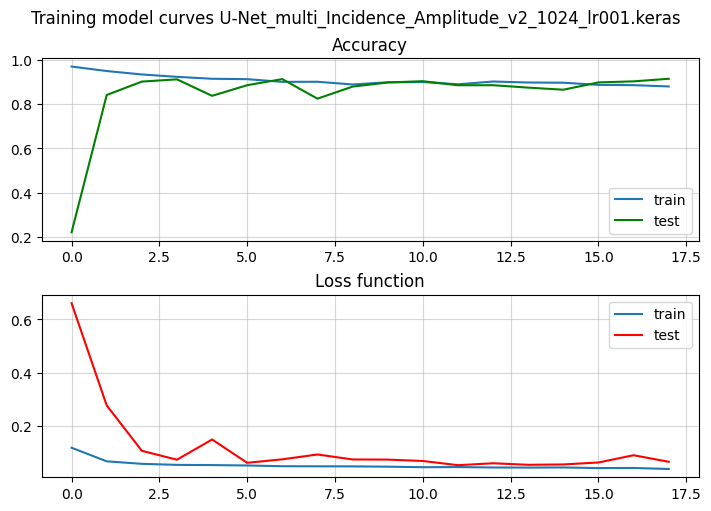

In [158]:
# plotting the loss and metric evaluation curves
mpl.rcParams['figure.figsize'] = (7,5)
fig,ax = plt.subplots(2,1,layout='constrained')
plt.suptitle(f'Training model curves {name_model}')
ax[0].plot(model_history.history['accuracy'],label='train')
ax[0].plot(model_history.history['val_accuracy'], color='green',label = 'test')
ax[0].grid(alpha=0.5)
ax[0].set_title('Accuracy')
ax[0].legend()

ax[1].plot(model_history.history['loss'],label = 'train')
ax[1].plot(model_history.history['val_loss'],color='red',label = 'test')
ax[1].grid(alpha=0.5)
ax[1].set_title('Loss function')
ax[1].legend()

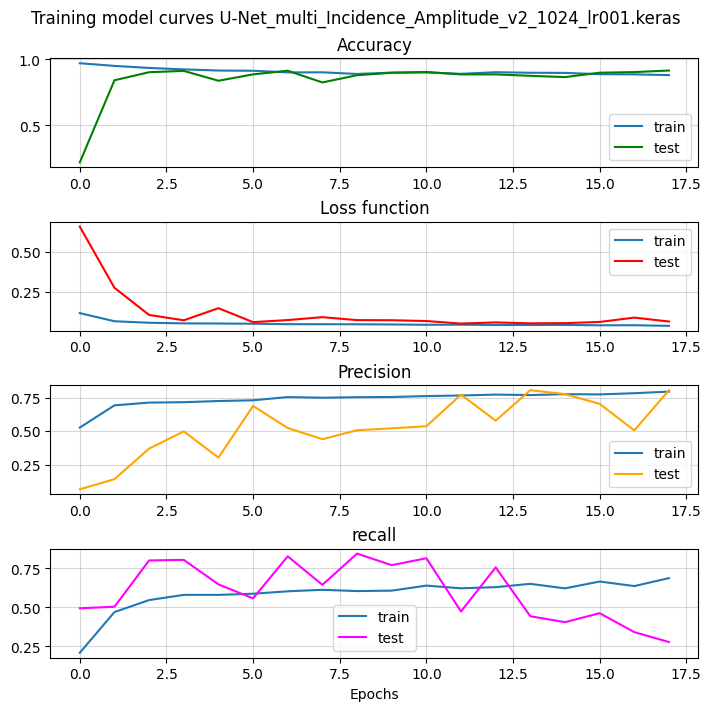

In [159]:
# plotting the loss and metric evaluation curves
mpl.rcParams['figure.figsize'] = (7,7)
fig,ax = plt.subplots(4,1,layout='constrained')
plt.suptitle(f'Training model curves {name_model}')
ax[0].plot(model_history.history['accuracy'],label='train')
ax[0].plot(model_history.history['val_accuracy'], color='green',label = 'test')
ax[0].grid(alpha=0.5)
ax[0].set_title('Accuracy')
ax[0].legend()

ax[1].plot(model_history.history['loss'],label = 'train')
ax[1].plot(model_history.history['val_loss'],color='red',label = 'test')
ax[1].grid(alpha=0.5)
ax[1].set_title('Loss function')
ax[1].legend()

ax[2].plot(model_history.history['precision'],label = 'train')
ax[2].plot(model_history.history['val_precision'],color='orange',label = 'test')
ax[2].grid(alpha=0.5)
ax[2].set_title('Precision')
ax[2].legend()

ax[3].plot(model_history.history['recall'],label = 'train')
ax[3].plot(model_history.history['val_recall'],color='magenta',label = 'test')
ax[3].grid(alpha=0.5)
ax[3].set_title('recall')
ax[3].set_xlabel('Epochs')
ax[3].legend()

In [144]:
model_history.history['recall'][0]

0.4488852918148041

In [145]:
ytest.shape

TensorShape([348, 5000, 2])

In [160]:
p_test = unet_model.predict(Xtest[:,:,:])#.argmax(axis=0)
p_good = np.empty_like(p_test)

for k in range(p_test.shape[-1]):
    for i in range(p_test.shape[0]):
        for j in range(p_test.shape[1]):
            if p_test[i,j,k] < 0.5:
                p_good[i,j,k] = 0
            else:
                p_good[i,j,k] = 1

11/11 [==============================] - 37s 3s/step


In [161]:
# Computing F1-Score
f1 = np.zeros((len(model_history.history['recall'])))

for k in range(len(model_history.history['recall'])):
    f1[k] = (2*model_history.history['recall'][k]*model_history.history['precision'][k])/(model_history.history['recall'][k] + 
                                                                                   model_history.history['precision'][k])

model_history.history['F1'] = list(f1)


In [162]:
from sklearn.metrics import matthews_corrcoef as mcc
mcc_P = [mcc(ytest[i,:4992,0], p_good[i,:,0]) for i in range(ytest.shape[0])]
mcc_S = [mcc(ytest[i,:4992,1], p_good[i,:,1]) for i in range(ytest.shape[0])]

model_history.history['MCC_P'] = mcc_P
model_history.history['MCC_S'] = mcc_S

In [163]:
print(f'Matthews Correlation Coefficient: P {np.mean(mcc_P):.3f}')
print(f'Matthews Correlation Coefficient: S {np.mean(mcc_S):.3f}')

Matthews Correlation Coefficient: P 0.425
Matthews Correlation Coefficient: S 0.245


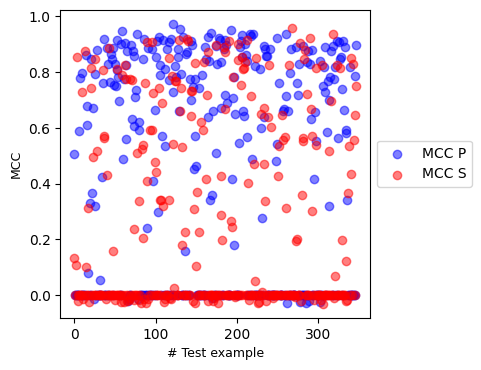

In [164]:
fig = plt.figure(figsize=(4,4))
x = np.arange(0,ytest.shape[0])
plt.scatter(x,mcc_P,color='blue',alpha=0.5,label='MCC P')
plt.scatter(x,mcc_S,color='red',alpha=0.5,label='MCC S')
plt.xlabel('# Test example',fontsize=9)
plt.ylabel('MCC',fontsize=9)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.savefig('MCC Amplitude Mod Label.png',dpi=200,bbox_inches='tight',pad_inches=0.05,transparent=True)

In [ ]:
fig = plt.figure(figsize=(4,4))
x = np.arange(0,ytest.shape[0])
plt.scatter(mcc_P,mcc_S,color='black',alpha=0.5,label='MCC P')
#plt.scatter(x,mcc_S,color='red',alpha=0.5,label='MCC S')
plt.xlabel('MCC P',fontsize=9)
plt.ylabel('MCC S',fontsize=9)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [ ]:
# Saving Training Curves:
hist_Inc_Amp = model_history.history
savemat('../Reports/History_Incidence_Amplitude_Mod_Label_lr2',hist_Inc_Amp)

In [165]:
# Test evaluation through Confusion matrix
p_test3 = unet_model.predict(Xtest)
print(f'Statistical Summary of Model predictions: \n \
Mean = {np.mean(p_test3)} \n Min = {p_test3.min()} \n \
Max = {p_test3.max()}')

11/11 [==============================] - 37s 3s/step
Statistical Summary of Model predictions: 
 Mean = 0.01700473390519619 
 Min = 1.9947265172959305e-07 
 Max = 0.9830782413482666


In [114]:
# Test evaluation through Confusion matrix
p_test3 = unet_model_L2.predict(Xtest)
print(f'Statistical Summary of Model predictions: \n \
Mean = {np.mean(p_test3)} \n Min = {p_test3.min()} \n \
Max = {p_test3.max()}')

11/11 [==============================] - 19s 2s/step
Statistical Summary of Model predictions: 
 Mean = 0.023304590955376625 
 Min = 0.0005979160196147859 
 Max = 0.2356671392917633


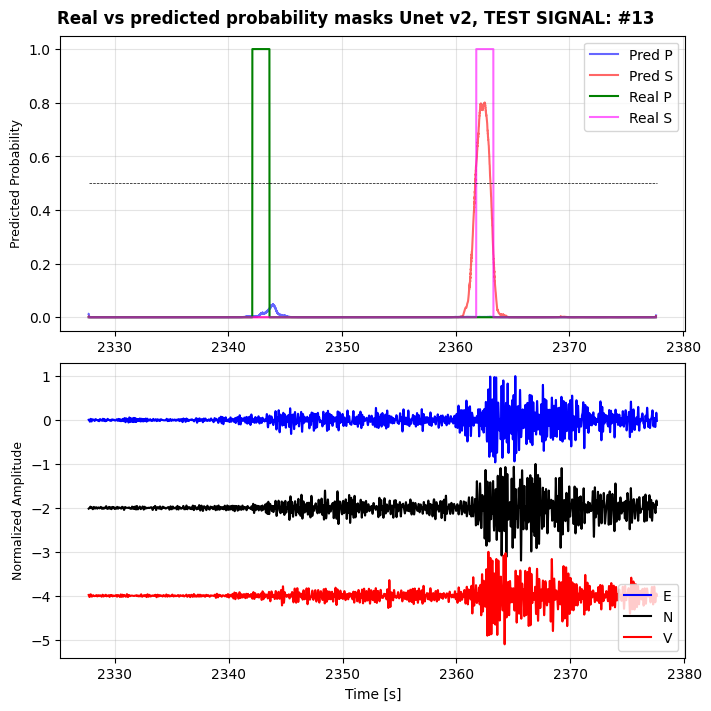

In [171]:
%matplotlib inline
nsig = np.random.randint(ytest.shape[0])
#nsig = 88#83#150 26
mpl.rcParams['figure.figsize']=(7,7)
fig,ax = plt.subplots(2,1,layout='constrained')
plt.suptitle(f'Real vs predicted probability masks Unet v2, TEST SIGNAL: #{nsig}',fontsize=12,weight='bold')
#ax[0].plot(t_test[nsig,:4992],p_test2[nsig,:,0],label = 'Predicted mask',color='magenta')
ax[0].plot(t_test[nsig,:4992],p_test3[nsig,:,0],alpha = 0.6,label = 'Pred P',color='blue')
ax[0].plot(t_test[nsig,:4992],p_test3[nsig,:,1],alpha = 0.6,label = 'Pred S',color='red')
ax[0].plot(t_test[nsig,:4992],ytest[nsig,:4992,0],label = 'Real P',color='green')
ax[0].plot(t_test[nsig,:4992],ytest[nsig,:4992,1],alpha = 0.6,label = 'Real S',color='magenta')
ax[0].hlines(0.5,t_test[nsig,0],t_test[nsig,-1],linestyle='--',color='k',linewidth=0.5)
#ax[0].plot(p_test2[nsig,:,1],label = 'Pred P mask')
#ax[0].plot(p_test2[nsig,:,2],label = 'Pred S mask')
ax[0].set_ylabel('Predicted Probability',fontsize=9)
ax[0].grid(alpha=0.333)
ax[0].legend()

ax[1].plot(t_test[nsig,:4992],Xtest[nsig,:4992,0],label = 'E',color = 'blue')
ax[1].plot(t_test[nsig,:4992],-2 + Xtest[nsig,:4992,1],label = 'N', color = 'black')
ax[1].plot(t_test[nsig,:4992],-4 + Xtest[nsig,:4992,2],label = 'V', color = 'red')
ax[1].set_xlabel('Time [s]',fontsize=10)
ax[1].set_ylabel('Normalized Amplitude',fontsize=9)
ax[1].grid(alpha=0.333)
ax[1].legend()

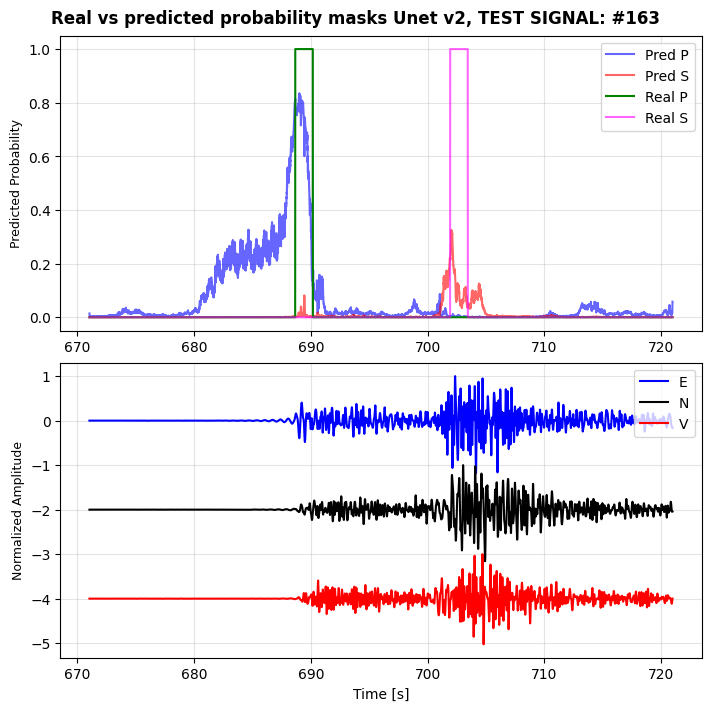

In [69]:
%matplotlib inline
nsig = 163#np.random.randint(340)
#nsig = 88#83#150 26
mpl.rcParams['figure.figsize']=(7,7)
fig,ax = plt.subplots(2,1,layout='constrained')
plt.suptitle(f'Real vs predicted probability masks Unet v2, TEST SIGNAL: #{nsig}',fontsize=12,weight='bold')
#ax[0].plot(t_test[nsig,:4992],p_test2[nsig,:,0],label = 'Predicted mask',color='magenta')
ax[0].plot(t_test[nsig,:4992],p_test3[nsig,:,0],alpha = 0.6,label = 'Pred P',color='blue')
ax[0].plot(t_test[nsig,:4992],p_test3[nsig,:,1],alpha = 0.6,label = 'Pred S',color='red')
ax[0].plot(t_test[nsig,:4992],ytest[nsig,:4992,0],label = 'Real P',color='green')
ax[0].plot(t_test[nsig,:4992],ytest[nsig,:4992,1],alpha = 0.6,label = 'Real S',color='magenta')
#ax[0].plot(p_test2[nsig,:,1],label = 'Pred P mask')
#ax[0].plot(p_test2[nsig,:,2],label = 'Pred S mask')
ax[0].set_ylabel('Predicted Probability',fontsize=9)
ax[0].grid(alpha=0.333)
ax[0].legend()

ax[1].plot(t_test[nsig,:4992],Xtest[nsig,:4992,0],label = 'E',color = 'blue')
ax[1].plot(t_test[nsig,:4992],-2 + Xtest[nsig,:4992,1],label = 'N', color = 'black')
ax[1].plot(t_test[nsig,:4992],-4 + Xtest[nsig,:4992,2],label = 'V', color = 'red')
ax[1].set_xlabel('Time [s]',fontsize=10)
ax[1].set_ylabel('Normalized Amplitude',fontsize=9)
ax[1].grid(alpha=0.333)
ax[1].legend()

## Good looking results 

In [70]:
#n = np.random.randint(p_test3.shape[0],size=12)
nn = [147,  88, 145, 154, 243,  71, 164, 216, 270,  29, 175, 153]

nn.append(np.random.randint(p_test3.shape[0]))
nn.append(np.random.randint(p_test3.shape[0]))
nn.append(np.random.randint(p_test3.shape[0]))
nn

[147, 88, 145, 154, 243, 71, 164, 216, 270, 29, 175, 153, 250, 55, 59]

In [71]:
nn = [147, 88, 145, 154, 243, 71, 164, 216, 270, 29, 173, 153, 33, 233, 115]

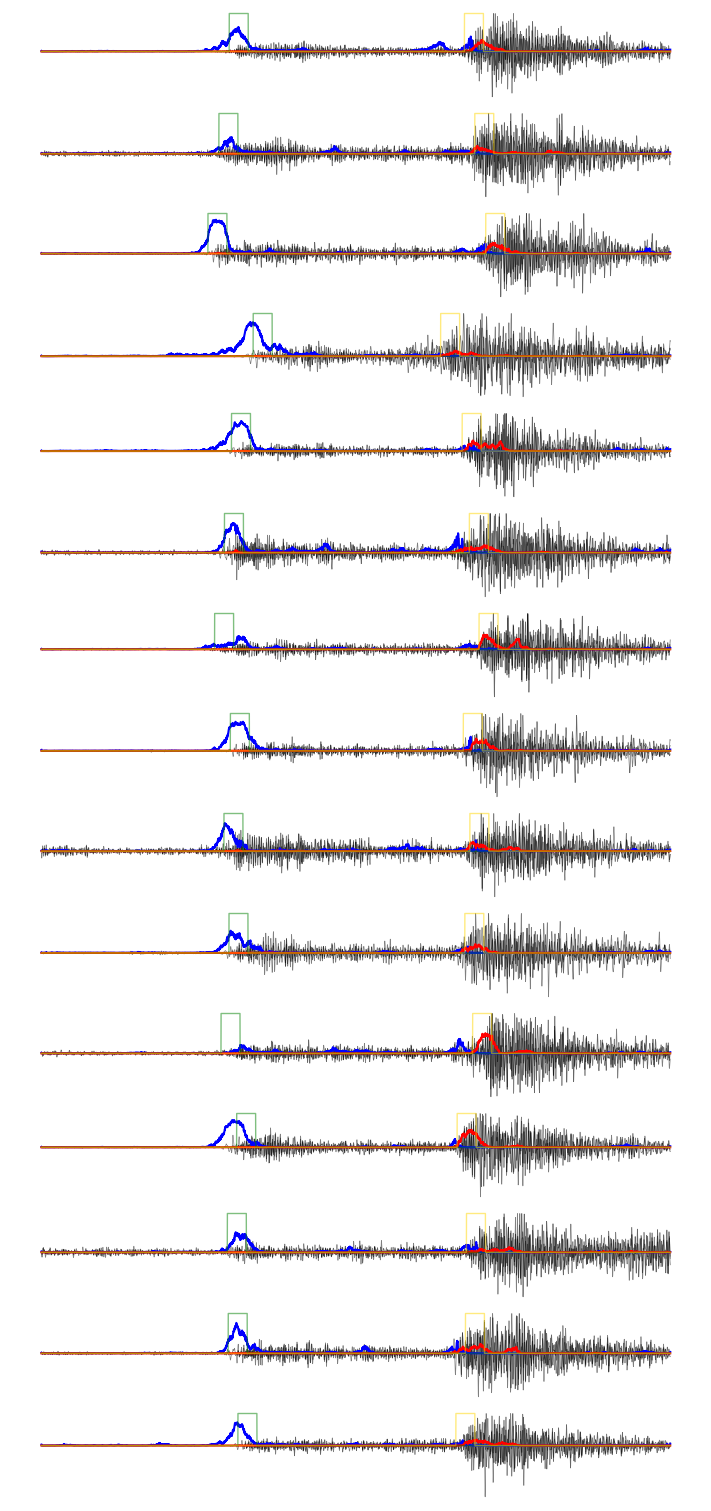

In [72]:

mpl.rcParams['figure.figsize'] = (7,15)
fig,ax = plt.subplots(15,1,layout='constrained')
#plt.figure(figsize=(10,2))
for i in range(15):
    n = nn[i]
    ax[i].plot(t_test[n,:4992],Xtest[n,:4992,0],color = 'black',alpha=0.5,linewidth=0.5)
    ax[i].plot(t_test[n,:4992],Xtest[n,:4992,1],color = 'black',alpha=0.6,linewidth=0.5)
    ax[i].plot(t_test[n,:4992],Xtest[n,:4992,2],color = 'black',alpha=0.5,linewidth=0.5)
    ax[i].plot(t_test[n,:4992],p_test3[n,:,0],c='blue')
    ax[i].plot(t_test[n,:4992],p_test3[n,:,1],c='red')
    
    ax[i].plot(t_test[n,:4992],ytest[n,:4992,0],c='green',alpha=0.5,linewidth=1)
    ax[i].plot(t_test[n,:4992],ytest[n,:4992,1],c='gold',alpha=0.5,linewidth=1)
    
    #ax[i].set_title(f'# {n}',fontsize=5)
    ax[i].axis('off')
    ax[i].tick_params(left = True, right = False , labelleft = True ,
                    labelbottom = False, bottom = False, labeltop = False)
#fig.savefig('Example 15 Signals.png',dpi=200,bbox_inches='tight',pad_inches=0.05,transparent=False)

In [ ]:
nn = np.random.randint(p_test3.shape[0],size=15)

In [73]:
nn = [ 83, 202, 220,  70, 141,  78, 252, 246,  93,  47, 112, 208,  60, 267, 107]

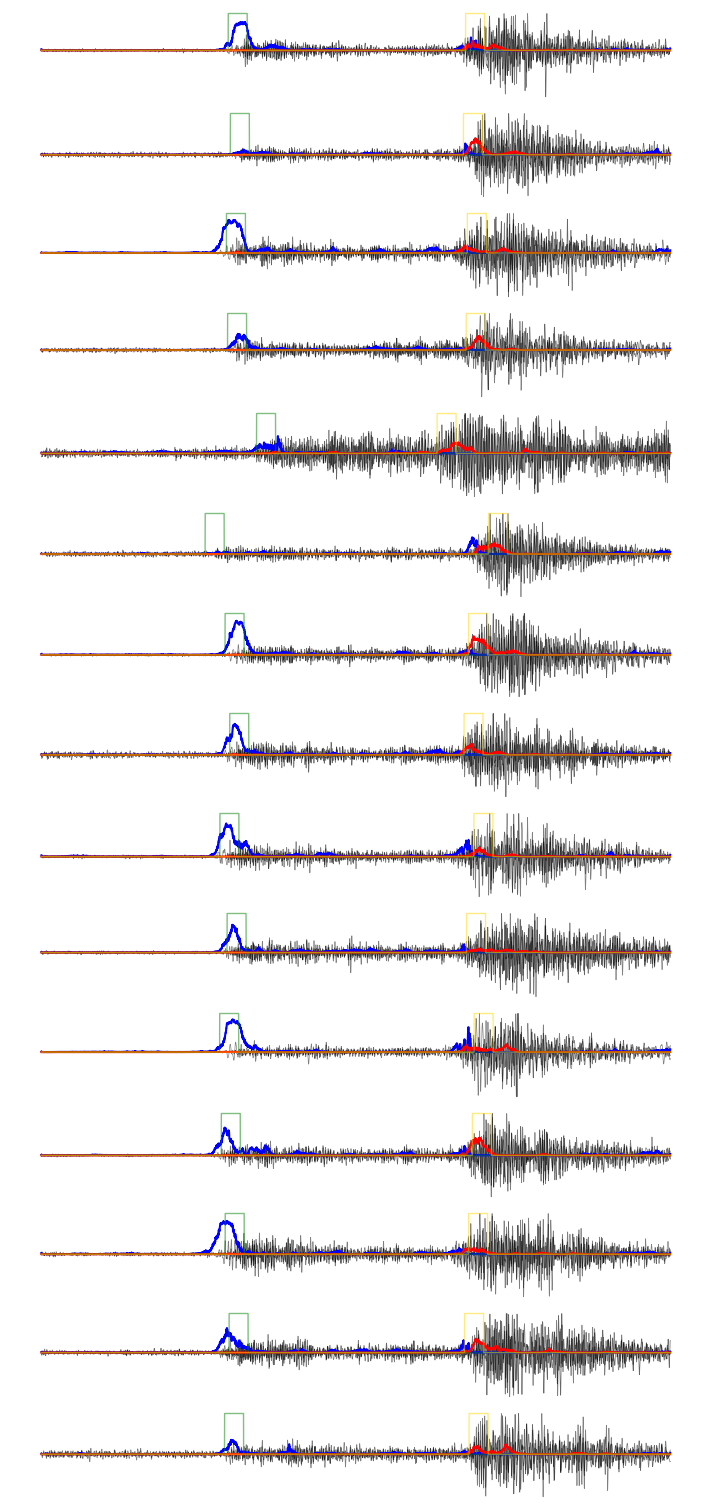

In [74]:
mpl.rcParams['figure.figsize'] = (7,15)
fig,ax = plt.subplots(15,1,layout='constrained')
#plt.figure(figsize=(10,2))
for i in range(15):
    n = nn[i]
    ax[i].plot(t_test[n,:4992],Xtest[n,:4992,0],color = 'black',alpha=0.5,linewidth=0.5)
    ax[i].plot(t_test[n,:4992],Xtest[n,:4992,1],color = 'black',alpha=0.6,linewidth=0.5)
    ax[i].plot(t_test[n,:4992],Xtest[n,:4992,2],color = 'black',alpha=0.5,linewidth=0.5)
    ax[i].plot(t_test[n,:4992],p_test3[n,:,0],c='blue')
    ax[i].plot(t_test[n,:4992],p_test3[n,:,1],c='red')
    
    ax[i].plot(t_test[n,:4992],ytest[n,:4992,0],c='green',alpha=0.5,linewidth=1)
    ax[i].plot(t_test[n,:4992],ytest[n,:4992,1],c='gold',alpha=0.5,linewidth=1)
    
    #ax[i].set_title(f'# {n}',fontsize=5)
    ax[i].axis('off')
    ax[i].tick_params(left = True, right = False , labelleft = True ,
                    labelbottom = False, bottom = False, labeltop = False)
#fig.savefig('Example 15 Signals 2.png',dpi=200,bbox_inches='tight',pad_inches=0.05,transparent=True)

### Layers inspections

In [75]:
for layer in unet_model_2.layers:
    print(f'Unet 1D model layers: {layer}')

Unet 1D model layers: <keras.engine.input_layer.InputLayer object at 0x7f35974d9fa0>
Unet 1D model layers: <keras.layers.convolutional.conv1d.Conv1D object at 0x7f3595469d00>
Unet 1D model layers: <keras.layers.normalization.batch_normalization.BatchNormalization object at 0x7f35953e6d30>
Unet 1D model layers: <keras.layers.core.activation.Activation object at 0x7f35d38f03d0>
Unet 1D model layers: <keras.layers.convolutional.conv1d.Conv1D object at 0x7f35d38f0f70>
Unet 1D model layers: <keras.layers.normalization.batch_normalization.BatchNormalization object at 0x7f35d38f0eb0>
Unet 1D model layers: <keras.layers.core.activation.Activation object at 0x7f35d38d1ee0>
Unet 1D model layers: <keras.layers.convolutional.conv1d.Conv1D object at 0x7f35d38d8fa0>
Unet 1D model layers: <keras.layers.normalization.batch_normalization.BatchNormalization object at 0x7f35d3864ac0>
Unet 1D model layers: <keras.layers.core.activation.Activation object at 0x7f35d3864e50>
Unet 1D model layers: <keras.laye

In [ ]:
len(unet_model_2.layers)

# Model Evaluation with Precision, recall and F1 Score

In [ ]:
#p_test = unet_model.predict(Xtest[:,:,:])#.argmax(axis=0)
p_good = np.empty_like(p_test3)

for k in range(p_test3.shape[-1]):
    for i in range(p_test3.shape[0]):
        for j in range(p_test3.shape[1]):
            if p_test3[i,j,k] < 0.5:
                p_good[i,j,k] = 0
            else:
                p_good[i,j,k] = 1

In [ ]:
from sklearn.metrics import precision_recall_fscore_support as prf

sumnpp = 0 ; sumnrp = 0 ; sumnsp = 0
sumnps = 0 ; sumnrs = 0 ; sumnss = 0
sumnfp = 0 ; sumnfs = 0
sumpp = 0 ; sumpr = 0 ; sumpf = 0 ; sumps = 0
sumsp = 0 ; sumsr = 0 ; sumsf = 0 ; sumss = 0
nsamp = p_good.shape[0]

for i in range(nsamp):
    pp,rp,fp,sp = prf(ytest[i,:4992,0],p_good[i,:4992,0])
    sumnpp += pp[0] ; sumnrp += rp[0] ; sumnfp += fp[0] ; sumnsp += sp[0]
    sumpp += pp[1] ; sumpr += rp[1]   ; sumpf += fp[1]  ; sumps += sp[1]
    
    ps,rs,fs,ss = prf(ytest[i,:4992,1],p_good[i,:4992,1])
    sumnps += ps[0] ; sumnrs += rs[0] ; sumnfs += fs[0] ; sumnss += ss[0]
    sumsp += ps[1] ; sumsr += rs[1]   ; sumsf += fs[1]  ; sumss += ss[1]

In [ ]:
avg_npp = sumnpp/nsamp
avg_nrp = sumnrp/nsamp
avg_nfp = sumnfp/nsamp

avg_pp = sumpp/nsamp
avg_pr = sumpr/nsamp
avg_pf = sumpf/nsamp

avg_nps = sumnps/nsamp
avg_nrs = sumnrs/nsamp
avg_nfs = sumnfs/nsamp

avg_sp = sumsp/nsamp
avg_sr = sumsr/nsamp
avg_sf = sumsf/nsamp

In [ ]:
print(f'Model {name_model} Evaluation: Precision, recall, F1 Score')
print(f'P Noise Precision: {avg_npp:.3f}')
print(f'P Noise Recall:    {avg_nrp:.3f}')
print(f'P Noise F1 score:  {avg_nfp:.3f}')
print('-------------------------------')
print(f'P phase Precision: {avg_pp:.3f}')
print(f'P phase Recall:    {avg_pr:.3f}')
print(f'P phase F1 score:  {avg_pf:.3f}')

In [ ]:
print(f'Model {name_model} Evaluation: Precision, recall, F1 Score')
print(f'S Noise Precision: {avg_nps:.3f}')
print(f'S Noise Recall:    {avg_nrs:.3f}')
print(f'S Noise F1 score:  {avg_nfs:.3f}')
print('-------------------------------')
print(f'S phase Precision: {avg_sp:.3f}')
print(f'S phase Recall:    {avg_sr:.3f}')
print(f'S phase F1 score:  {avg_sf:.3f}')

In [ ]:
# Matriz de confusión
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(model_name,cm,classes,flag,normalize=False,
                           title='Confusion Matrix',cmap = plt.cm.Reds):
    if normalize:    
        cm = cm.astype('float')/cm.sum(axis=1)[:,np.newaxis]
        print('matriz de confusión normalizada')
    else:
        print('Matriz de confusión sin normalización')
  
    print(cm)
    if flag == 'P': 
        #cmap = plt.cm.PuRd
        cmap = plt.cm.Reds
        clas = ['N','P']
    if flag == 'S': 
        cmap = plt.cm.YlGn
        clas = ['N','S']
    if flag == 'noise': cmap = plt.cm.Blues
        
    fig = plt.figure(figsize=(20,5))
    plt.imshow(cm,interpolation='nearest',cmap=cmap)
    plt.title(title+' '+model_name+f' {flag} Classification')
    #plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks,clas,rotation=45)
    plt.yticks(tick_marks,clas)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max()/2
    for i,j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
        plt.text(j,i,format(cm[i,j],fmt),
             horizontalalignment='center',
             color='white' if cm[i,j] > thresh else 'black')
        
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted label')
    plt.savefig(f'Confusion Matrix {model_name} {flag} Classification.png',
                dpi=200,bbox_inches='tight',pad_inches=0.05,transparent = True)

In [ ]:
p_good_pv = np.zeros((p_test3.shape[0] * p_test3.shape[1]),dtype=int)
p_good_sv = np.zeros((p_test3.shape[0] * p_test3.shape[1]),dtype=int)
ytest_pv = np.zeros((ytest.shape[0] * p_test3.shape[1]),dtype=int)
ytest_sv = np.zeros((ytest.shape[0] * p_test3.shape[1]),dtype=int)
#ytestv = np.zeros((2*4992),dtype = int)
    
for i in range(p_test3.shape[0]):
    for j in range(p_test3.shape[1]):
        k = j + i*p_test3.shape[1]
        if p_good[i,j,0] == 1: 
            p_good_pv[k] = 1
        else:
            p_good_pv[k] = 0

for i in range(p_test3.shape[0]):
    for j in range(p_test3.shape[1]):
        k = j + i*p_test3.shape[1]
        if p_good[i,j,1] == 1: 
            p_good_sv[k] = 1
        else:
            p_good_sv[k] = 0

In [ ]:
for i in range(p_test3.shape[0]):#(ytest[:2].shape[0]):
    for j in range(p_test3.shape[1]):
        k = j + i*p_test3.shape[1]
        if ytest[i,j,0] == 1: 
            ytest_pv[k] = 1
        else:
            ytest_pv[k] = 0
            
for i in range(p_test3.shape[0]):#(ytest[:2].shape[0]):
    for j in range(p_test3.shape[1]):
        k = j + i*p_test3.shape[1]
        if ytest[i,j,1] == 1: 
            ytest_sv[k] = 1
        else:
            ytest_sv[k] = 0

In [ ]:
# Confusion matrix for P-classification
flag = 'P'
cm = confusion_matrix(ytest_pv,p_good_pv)
plot_confusion_matrix(name_model,cm,list(range(2)),flag)

# Confusion matrix for S-classification
flag = 'S'
cm = confusion_matrix(ytest_sv,p_good_sv)
plot_confusion_matrix(name_model,cm,list(range(2)),flag)

## Quick evaluation: predicted vs test data

In [ ]:
# # Test evaluation through Confusion matrix
# p_test = unet_model.predict(test_batches)#.argmax(axis=0)
# #p_test = unet_model.predict(Xtest)
# print(f'Statistical Summary of Model predictions: \n \
# Mean = {np.mean(p_test)} \n Min = {p_test.min()} \n \
# Max = {p_test.max()}')

In [ ]:
# Multiclassification
#predictions = np.argmax(model.predict(x_test), axis=-1)
# Binary classes
pred_class = (unet_model_2.predict(Xtest) > 0.6).astype("int32")

In [ ]:
pred_class.shape

In [ ]:
nsig = np.random.randint(340)
#nsig = 150
mpl.rcParams['figure.figsize']=(7,7)
fig,ax = plt.subplots(3,1,layout='constrained')
plt.suptitle(f'Real vs predicted probability masks, TEST SIGNAL: #{nsig}',fontsize=12,weight='bold')
ax[0].plot(t_test[nsig,:4992],p_test3[nsig,:,0],label = 'Pred P',color='cyan')
ax[0].plot(t_test[nsig,:4992],p_test3[nsig,:,1],label = 'Pred S',color='magenta')
#ax[0].plot(t_test[nsig,:4992],pred_class[nsig,:,0],label = 'Predicted classes',color='cyan')
#ax[0].plot(p_test2[nsig,:,2],label = 'Pred S mask')
ax[0].set_ylabel('Predicted Probability',fontsize=9)
ax[0].grid(alpha=0.333)
ax[0].legend()

ax[1].plot(t_test[nsig,:4992],ytest[nsig,:4992,0],label = 'Real P',color='blue')
ax[1].plot(t_test[nsig,:4992],ytest[nsig,:4992,1],label = 'Real S',color='red')
ax[1].plot(t_test[nsig,:4992],pred_class[nsig,:,0],alpha = 0.6,label = 'Pred P-mask',color='cyan')
ax[1].plot(t_test[nsig,:4992],pred_class[nsig,:,1],alpha = 0.6,label = 'Pred S-mask',color='magenta')
#ax[1].plot(ytest[nsig,:,1],label = 'Real P mask')
#ax[1].plot(ytest[nsig,:,2],label = 'Real S mask')
#ax[1].set_xlabel('Time samples')
ax[1].set_ylabel('Probability',fontsize=9)
ax[1].grid(alpha=0.333)
ax[1].legend()

ax[2].plot(t_test[nsig,:4992],Xtest[nsig,:4992,0],label = 'E',color = 'blue')
ax[2].plot(t_test[nsig,:4992],-2 + Xtest[nsig,:4992,1],label = 'N', color = 'black')
ax[2].plot(t_test[nsig,:4992],-4 + Xtest[nsig,:4992,2],label = 'V', color = 'red')
ax[2].set_xlabel('Time [s]',fontsize=10)
ax[2].set_ylabel('Normalized Amplitude',fontsize=9)
ax[2].grid(alpha=0.333)
ax[2].legend()

In [ ]:
pred_class.shape

In [ ]:
nsig = np.random.randint(340)
#nsig = 88#83#150
mpl.rcParams['figure.figsize']=(7,7)
fig,ax = plt.subplots(2,1,layout='constrained')
plt.suptitle(f'Real vs predicted probability masks Unet Feature Engineering, TEST SIGNAL: #{nsig}',fontsize=12,weight='bold')
#ax[0].plot(t_test[nsig,:4992],p_test2[nsig,:,0],label = 'Predicted mask',color='magenta')
ax[0].plot(t_test[nsig,:4992],p_test3[nsig,:,0],alpha = 0.6,label = 'Pred P',color='blue')
ax[0].plot(t_test[nsig,:4992],p_test3[nsig,:,1],alpha = 0.6,label = 'Pred S',color='red')
ax[0].plot(t_test[nsig,:4992],ytest[nsig,:4992,0],label = 'Real P',color='green')
ax[0].plot(t_test[nsig,:4992],ytest[nsig,:4992,1],alpha = 0.6,label = 'Real S',color='magenta')
#ax[0].plot(p_test2[nsig,:,1],label = 'Pred P mask')
#ax[0].plot(p_test2[nsig,:,2],label = 'Pred S mask')
ax[0].set_ylabel('Predicted Probability',fontsize=9)
ax[0].grid(alpha=0.333)
ax[0].legend()

# ax[1].plot(t_test[nsig,:4992],ytest[nsig,:4992,0],label = 'Real P',color='green')
# ax[1].plot(t_test[nsig,:4992],ytest[nsig,:4992,1],alpha = 0.6,label = 'Real S',color='magenta')
# #ax[1].plot(t_test[nsig,:4992],p_test2[nsig,:,1],alpha = 0.6,label = 'Predicted mask',color='magenta')
# #ax[1].plot(ytest[nsig,:,1],label = 'Real P mask')
# #ax[1].plot(ytest[nsig,:,2],label = 'Real S mask')
# #ax[1].set_xlabel('Time samples')
# ax[1].set_ylabel('Probability',fontsize=9)
# ax[1].grid(alpha=0.333)
# ax[1].legend()

ax[1].plot(t_test[nsig,:4992],Xtest[nsig,:4992,0],label = 'E',color = 'blue')
ax[1].plot(t_test[nsig,:4992],-2 + Xtest[nsig,:4992,1],label = 'N', color = 'black')
ax[1].plot(t_test[nsig,:4992],-4 + Xtest[nsig,:4992,2],label = 'V', color = 'red')
ax[1].set_xlabel('Time [s]',fontsize=10)
ax[1].set_ylabel('Normalized Amplitude',fontsize=9)
ax[1].grid(alpha=0.333)
ax[1].legend()

In [ ]:
for j in range(ytest.shape[0]):
    mpl.rcParams['figure.figsize']=(7,7)
    fig,ax = plt.subplots(3,1,layout='constrained')
    plt.suptitle(f'Real vs predicted probability masks, TEST SIGNAL: #{j}',fontsize=12,weight='bold')
    ax[0].plot(t_test[j,:4992],p_test3[j,:,0],label = 'Predicted mask',color='magenta')
    ax[0].plot(t_test[j,:4992],pred_class[j,:,0],label = 'Predicted classes',color='cyan')
    #ax[0].plot(p_test2[nsig,:,2],label = 'Pred S mask')
    ax[0].set_ylabel('Predicted Probability',fontsize=9)
    ax[0].grid(alpha=0.333)
    ax[0].legend()

    ax[1].plot(t_test[j,:4992],ytest[j,:4992],label = 'Real mask',color='green')
    ax[1].plot(t_test[j,:4992],p_test3[j,:,0],alpha = 0.6,label = 'Predicted mask',color='magenta')
    #ax[1].plot(ytest[nsig,:,1],label = 'Real P mask')
    #ax[1].plot(ytest[nsig,:,2],label = 'Real S mask')
    #ax[1].set_xlabel('Time samples')
    ax[1].set_ylabel('Probability',fontsize=9)
    ax[1].grid(alpha=0.333)
    ax[1].legend()

    ax[2].plot(t_test[j,:4992],Xtest[j,:4992,0],label = 'E',color = 'blue')
    ax[2].plot(t_test[j,:4992],-2 + Xtest[j,:4992,1],label = 'N', color = 'black')
    ax[2].plot(t_test[j,:4992],-4 + Xtest[j,:4992,2],label = 'V', color = 'red')
    ax[2].set_xlabel('Time [s]',fontsize=10)
    ax[2].set_ylabel('Normalized Amplitude',fontsize=9)
    ax[2].grid(alpha=0.333)
    ax[2].legend()
    
    path = 'Resultados_unet_picking_FEng_Mult_Out_Depurada1/'
    isExist = os.path.exists(path)
    if not isExist:
        os.makedirs(path)
    
    fig.savefig(f'{path}Prediction_{j}_signal.png',dpi=100,bbox_inches='tight',pad_inches=0.05,
               transparent=True)
    plt.close(fig)

In [ ]:
p_test2.shape

In [ ]:
for j in range(ytest.shape[0]):
    mpl.rcParams['figure.figsize']=(7,7)
    fig,ax = plt.subplots(2,1,layout='constrained')
    plt.suptitle(f'Real vs predicted probability masks, TEST SIGNAL: #{j}',fontsize=12,weight='bold')

    ax[0].plot(t_test[j,:4992],ytest[j,:4992,0],label = 'Real P',color = 'green')
    ax[0].plot(t_test[j,:4992],ytest[j,:4992,1],label = 'Real S',color = 'magenta')
    ax[0].plot(t_test[j,:4992],p_test3[j,:,0],label = 'Pred P', color='blue')
    ax[0].plot(t_test[j,:4992],p_test3[j,:,1],label = 'Pred S', color='red')
    ax[0].set_ylabel('Probability',fontsize=9)
    ax[0].grid(alpha=0.333)
    ax[0].legend()

    ax[1].plot(t_test[j,:4992],Xtest[j,:4992,0],label = 'E',color = 'blue')
    ax[1].plot(t_test[j,:4992],-2 + Xtest[j,:4992,1],label = 'N', color = 'black')
    ax[1].plot(t_test[j,:4992],-4 + Xtest[j,:4992,2],label = 'V', color = 'red')
    ax[1].set_xlabel('Time [s]')
    ax[1].set_ylabel('Normalized Amplitude',fontsize=9)
    ax[1].grid(alpha=0.333)
    ax[1].legend()
    
    path = 'Resultados_unet_picking_FEng_Mult_Out_Depurada1/'
    isExist = os.path.exists(path)
    if not isExist:
        os.makedirs(path)
    
    fig.savefig(f'{path}Prediction_{j}_signal.png',dpi=100,bbox_inches='tight',pad_inches=0.05,
               transparent=True)
    plt.close(fig)

# Model Evaluation

In [ ]:
def model_test_evaluation_multiclass(scores,model,Xtest,ytest,model_name,flag):
    
    print('Test loss:', scores[0])
    print('Test accuracy:', scores[1])

    # Test evaluation through Confusion matrix
    p_test = model.predict(Xtest)#.argmax(axis=0)
    p_good = np.empty_like(p_test)
    
    for i in range(p_test.shape[0]):
        for j in range(p_test.shape[1]):
            if p_test[i,j] <= 0.5:
                p_good[i,j] = 0
            else:
                p_good[i,j] = 1
        
    p_goodv = np.zeros((p_test.shape[0]),dtype=int)
    ytestv = np.zeros((ytest.shape[0]),dtype=int)
    
    for i in range(p_test.shape[0]):
        if p_good[i,0] == 1: 
            p_goodv[i] = 0
        elif p_good[i,1] == 1:
            p_goodv[i] = 1
#         elif p_good[i,2] == 1:
#             p_goodv[i] = 2
    
    for i in range(ytest.shape[0]):
        if ytest[i,0] == 1: 
            ytestv[i] = 0
        elif ytest[i,1] == 1:
            ytestv[i] = 1
#         elif ytest[i,2] == 1:
#             ytestv[i] = 2
    
    #print(ytestv)
    #print(p_goodv)

    cm = confusion_matrix(ytestv,p_goodv)
    plot_confusion_matrix(model_name,cm,list(range(2)),flag)
    
    return p_goodv,ytestv,cm

In [ ]:
# Matriz de confusión
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(model_name,cm,classes,flag,normalize=False,
                           title='Confusion Matrix',cmap = plt.cm.Reds):
    if normalize:    
        cm = cm.astype('float')/cm.sum(axis=1)[:,np.newaxis]
        print('matriz de confusión normalizada')
    else:
        print('Matriz de confusión sin normalización')
  
    print(cm)
    if flag == 'regional': cmap = plt.cm.PuRd
    if flag == 'local': cmap = plt.cm.YlGn
    if flag == 'noise': cmap = plt.cm.Blues
        
    fig = plt.figure(figsize=(20,5))
    plt.imshow(cm,interpolation='nearest',cmap=cmap)
    plt.title(title+' '+model_name)
    #plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks,classes,rotation=45)
    plt.yticks(tick_marks,classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max()/2
    for i,j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
        plt.text(j,i,format(cm[i,j],fmt),
             horizontalalignment='center',
             color='white' if cm[i,j] > thresh else 'black')
        
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted label')
    plt.savefig(f'Confusion Matrix {model_name}.png',dpi=200,bbox_inches='tight',pad_inches=0.05)

# Model Evaluation with Precision, recall and F1 Score

In [ ]:
from sklearn.metrics import precision_recall_fscore_support as prf

In [ ]:
def plot_pred_vs_test(p_test,ytest,model_name):
    nsig = p_test.shape[0]
    mpl.rcParams['figure.figsize'] = (7,20)
    #fig,ax = plt.subplots(10,1,layout='constrained')
    aux = 0
    inter = [[0,10],[10,20],[20,30],[30,40]]#,[40,50],[50,60],[60,70],[70,80],[80,90],[90,100],[100,110],[110,120]]
    for j in inter:
        ini = j[0]
        fin = j[1]
        aux += 1
        print(j,ini,fin,aux)
        fig,ax = plt.subplots(10,1,layout='constrained')
        for idx,i in enumerate(range(ini,fin)):
            plt.suptitle(f'Real vs predicted probability masks {model_name}')
            ax[idx].plot(p_test[i,:,:,0],label = 'Pred P mask')
            ax[idx].plot(p_test[i,:,:,1],label = 'Pred S mask')
            ax[idx].plot(p_test[i,:,:,2],label = 'Pred Noise mask')
#             ax[idx].plot(time[i,:],ytest[i,:,:,0],alpha=0.5,label = 'Pred P mask')
#             ax[idx].plot(time[i,:],ytest[i,:,:,1],alpha=0.5,label = 'Pred S mask')
#             ax[idx].plot(time[i,:],ytest[i,:,:,2],alpha=0.5,label = 'Pred Noise mask')
            ax[idx].set_title(f'Signal # {i}',fontsize=8)      
            #fig.savefig(f'Model_Evaluation_Results_tuned_5depth/Test vs Prediction Batch {aux}.png',bbox_inches='tight',pad_inches=0.05,dpi=100

### UNet 1D: depth = 7

In [ ]:
# nsig = p_test.shape[0]
# mpl.rcParams['figure.figsize'] = (7,20)
# #fig,ax = plt.subplots(10,1,layout='constrained')
# aux = 0
# #inter = [[0,10],[10,20],[20,30],[30,40]]#,[40,50],[50,60],[60,70],[70,80],[80,90],[90,100],[100,110],[110,120]]
# inter = [[40,50],[50,60],[60,70],[70,80],[80,90]]
# for j in inter:
#     ini = j[0]
#     fin = j[1]
#     aux += 1
#     print(j,ini,fin,aux)
#     fig,ax = plt.subplots(10,1,layout='constrained')
#     for idx,i in enumerate(range(ini,fin)):
#         plt.suptitle(f'Real vs predicted probability masks {model_name}')
#         ax[idx].plot(p_test[i,:,:,0],label = 'Pred P mask')
#         ax[idx].plot(p_test[i,:,:,1],label = 'Pred S mask')
#         ax[idx].plot(p_test[i,:,:,2],label = 'Pred Noise mask')
# #             ax[idx].plot(time[i,:],ytest[i,:,:,0],alpha=0.5,label = 'Pred P mask')
# #             ax[idx].plot(time[i,:],ytest[i,:,:,1],alpha=0.5,label = 'Pred S mask')
# #             ax[idx].plot(time[i,:],ytest[i,:,:,2],alpha=0.5,label = 'Pred Noise mask')
#         ax[idx].set_title(f'Signal # {i}',fontsize=8)  

In [ ]:
def crop_and_concat_D5(net1, net2): #(Funciona para x_input:(5000,3))
    """
      the size(net1) <= size(net2)
    """
    ## dynamic shape
    chn1 = net1.get_shape().as_list()[-1]
    chn2 = net2.get_shape().as_list()[-1]
    net1_shape = tf.shape(net1)
    net2_shape = tf.shape(net2)
    print(f'chn1: {chn1}, chn2: {chn2}')
    print(f'net1_sh: {net1_shape}')
    print(f'net2_sh: {net2_shape}')
    #offsets = [0, (net2_shape[1] - net1_shape[1]) // 2, (net2_shape[2] - net1_shape[2]) // 2, 0]
    #offsets = [0, (net2_shape[1] - net1_shape[1]) // 2, (net2_shape[2] - net1_shape[2]) // 2]
    offsets = [0, (net2_shape[1] - net1_shape[1]) // 2, 0]
    #size = [-1, net1_shape[1], net1_shape[2], -1]
    size = [-1, net1_shape[1], -1]
    print(f'offsets: {offsets}')
    print(f'size: {size}')
    net2_resize = tf.slice(net2, offsets, size)

    out = tf.concat([net1, net2_resize], 2)
    out.set_shape([None,None, chn1+chn2])

    return out

# def crop_and_concat(net1, net2): #(Funciona para x_input:(5000,3))
#     """
#       the size(net1) <= size(net2)
#     """
#     ## dynamic shape
#     chn1 = net1.get_shape().as_list()[-1]
#     chn2 = net2.get_shape().as_list()[-1]
#     net1_shape = tf.shape(net1)
#     net2_shape = tf.shape(net2)
#     print(f'chn1: {chn1}, chn2: {chn2}')
#     print(f'net1_sh: {net1_shape}')
#     print(f'net2_sh: {net2_shape}')
#     #offsets = [0, (net2_shape[1] - net1_shape[1]) // 2, (net2_shape[2] - net1_shape[2]) // 2, 0]
#     #offsets = [0, (net2_shape[1] - net1_shape[1]) // 2, (net2_shape[2] - net1_shape[2]) // 2]
#     offsets = [0, (net2_shape[1] - net1_shape[1]) // 2,(net2_shape[2] - net1_shape[2]) // 2, 0]
#     size = [-1, net1_shape[1], net1_shape[2], -1]
#     #size = [-1, net1_shape[1], -1]
#     print(f'offsets: {offsets}')
#     print(f'size: {size}')
#     net2_resize = tf.slice(net2, offsets, size)

#     out = tf.concat([net1, net2_resize], 3)
#     out.set_shape([None,None,None, chn1+chn2])

#     return out 

def double_conv_block_D5(x, n_filters):

    # Conv2D then ReLU activation
    x = layers.Conv1D(n_filters, 3, padding = "same", kernel_initializer = "he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    # Conv2D then ReLU activation
    x = layers.Conv1D(n_filters, 3, padding = "same", kernel_initializer = "he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    # Conv2D then ReLU activation
    x = layers.Conv1D(n_filters, 3, padding = "same", kernel_initializer = "he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    # dropout
    x = layers.Dropout(0.2)(x)

    return x

def downsample_block_D5(x, n_filters):
    f = double_conv_block(x, n_filters)
    p = layers.MaxPool1D(2)(f)
    p = layers.Dropout(0.2)(p)

    return f, p

def upsample_block_D5(x, conv_features, n_filters):
    # upsample
    x = layers.Conv1DTranspose(n_filters, 3, 2, padding="same")(x)
    # concatenate
    #x = layers.concatenate([x, conv_features],axis=1)
    #x = layers.concatenate([x, conv_features],axis=-1)
    #x = crop_and_concat(x, conv_features)
    #x = crop_and_concat(conv_features,x)
    x = crop_and_concat(x,conv_features)
    # dropout
    x = layers.Dropout(0.2)(x)
    # Conv2D twice with ReLU activation
    x = double_conv_block(x, n_filters)

    return x

def build_unet_model_D5(x_input): # Main builder!!

    # inputs
    #inputs = layers.Input(shape=(5000,1,3))
    input_shape = tf.TensorShape(x_input[0,...].shape)
    inputs = layers.Input(shape=input_shape)

    # encoder: contracting path - downsample
    # 1 - downsample
    f1, p1 = downsample_block_D5(inputs, 64)
    # 2 - downsample
    f2, p2 = downsample_block_D5(p1, 128)
    # 3 - downsample
    f3, p3 = downsample_block_D5(p2, 256)
    # 4 - downsample
    f4, p4 = downsample_block_D5(p3, 512)
    # 5 - downsample
    f5, p5 = downsample_block_D5(p4, 1024)

    # 6 - bottleneck
    bottleneck = double_conv_block_D5(p5, 2048)
    bottleneck = layers.Dropout(0.3)(bottleneck)

    # decoder: expanding path - upsample
    # 7 - upsample
    u6 = upsample_block_D5(bottleneck, f5, 1024)
    # 8 - upsample
    u7 = upsample_block_D5(u6, f4, 512)
    # 8 - upsample
    u8 = upsample_block_D5(u7, f3, 256)
    # 9 - upsample
    u9 = upsample_block_D5(u8, f2, 128)
    # 10 - upsample
    u10 = upsample_block_D5(u9, f1, 64)

    # outputs
    x = layers.Conv1D(2, 1, padding="same", kernel_initializer = "he_normal")(u10)
    outputs = layers.TimeDistributed(Dense(2, activation='sigmoid', name = 'Output'))(x)
                              
    # unet model with Keras Functional API
    #net_model = tf.keras.Model(inputs, outputs, name="U-Net_multi")
    unet_model = tf.keras.Model(inputs, outputs, name="U-Net_multi_dense_FeatEng")

    return unet_model

In [ ]:
# Unet Image Segmentation Convolutional Neural Network definition:
name_model = "U-Net_multi_dense_FeatEng_Depth_5"
unet_model_D5 = build_unet_model_D5(x_input)
unet_model_D5.summary()
#loss = keras.losses.sparse_categorical_crossentropy()

In [ ]:
unet_model_D5.compile(optimizer=tf.keras.optimizers.Adam(),
                   loss='binary_crossentropy',
                   metrics=["accuracy"],)
                           #tf.keras.metrics.Recall(),
                           #tf.keras.metrics.Precision()])

In [ ]:
import time

keras.backend.clear_session()
NUM_EPOCHS = 20
BATCH_SIZE = 16
Ninput = int(X_input.shape[0])
STEPS_EPOCH = Ninput // BATCH_SIZE

VAL_SUBSPLITS = 5
VAL_STEPS = Xtest.shape[0] // BATCH_SIZE // VAL_SUBSPLITS

verbose = 2
start = time.time()
model_history = unet_model_D5.fit(Xtrain,ytrain[:,:4992],validation_data=(Xtest,ytest[:,:4992]),
                              epochs=NUM_EPOCHS,
                              verbose=verbose,
                              steps_per_epoch =  STEPS_EPOCH,
                              validation_steps = VAL_STEPS)

print(f'Unet 1D model Feature Engineering: {name_model} training time execution: {(time.time() - start)/60.0:.3f} minutes')

In [ ]:
# plotting the loss and metric evaluation curves
mpl.rcParams['figure.figsize'] = (7,5)
fig,ax = plt.subplots(2,1,layout='constrained')
plt.suptitle(f'Training model {name_model}')
ax[0].plot(model_history.history['accuracy'],label='train')
ax[0].plot(model_history.history['val_accuracy'], color='green',label = 'test')
ax[0].grid(alpha=0.5)
ax[0].set_title('Accuracy')
ax[0].legend()

ax[1].plot(model_history.history['loss'],label = 'train')
ax[1].plot(model_history.history['val_loss'],color='red',label = 'test')
ax[1].grid(alpha=0.5)
ax[1].set_title('Loss function')
ax[1].legend()

In [ ]:
# Test evaluation through Confusion matrix
p_testD5 = unet_model_D5.predict(Xtest)
print(f'Statistical Summary of Model predictions: \n \
Mean = {np.mean(p_testD5)} \n Min = {p_testD5.min()} \n \
Max = {p_testD5.max()}')

In [ ]:
# Multiclassification
#predictions = np.argmax(model.predict(x_test), axis=-1)
# Binary classes
pred_class_D5 = (unet_model_D5.predict(Xtest) > 0.5).astype("int32")

In [ ]:
nsig = np.random.randint(383)
nsig = 177
mpl.rcParams['figure.figsize']=(7,7)
fig,ax = plt.subplots(3,1,layout='constrained')
plt.suptitle(f'Real vs predicted probability masks, TEST SIGNAL: #{nsig}',fontsize=12,weight='bold')
ax[0].plot(t_test[nsig,:4992],p_testD5[nsig,:,0],label = 'Pred P',color='cyan')
ax[0].plot(t_test[nsig,:4992],p_testD5[nsig,:,1],label = 'Pred S',color='magenta')
#ax[0].plot(t_test[nsig,:4992],pred_class[nsig,:,0],label = 'Predicted classes',color='cyan')
#ax[0].plot(p_test2[nsig,:,2],label = 'Pred S mask')
ax[0].set_ylabel('Predicted Probability',fontsize=9)
ax[0].grid(alpha=0.333)
ax[0].legend()

ax[1].plot(t_test[nsig,:4992],ytest[nsig,:4992,0],label = 'Real P',color='blue')
ax[1].plot(t_test[nsig,:4992],ytest[nsig,:4992,1],label = 'Real S',color='red')
ax[1].plot(t_test[nsig,:4992],pred_class_D5[nsig,:,0],alpha = 0.6,label = 'Pred P-mask',color='cyan')
ax[1].plot(t_test[nsig,:4992],pred_class_D5[nsig,:,1],alpha = 0.6,label = 'Pred S-mask',color='magenta')
#ax[1].plot(ytest[nsig,:,1],label = 'Real P mask')
#ax[1].plot(ytest[nsig,:,2],label = 'Real S mask')
#ax[1].set_xlabel('Time samples')
ax[1].set_ylabel('Probability',fontsize=9)
ax[1].grid(alpha=0.333)
ax[1].legend()

ax[2].plot(t_test[nsig,:4992],Xtest[nsig,:4992,0],label = 'E',color = 'blue')
ax[2].plot(t_test[nsig,:4992],-2 + Xtest[nsig,:4992,1],label = 'N', color = 'black')
ax[2].plot(t_test[nsig,:4992],-4 + Xtest[nsig,:4992,2],label = 'V', color = 'red')
ax[2].set_xlabel('Time [s]',fontsize=10)
ax[2].set_ylabel('Normalized Amplitude',fontsize=9)
ax[2].grid(alpha=0.333)
ax[2].legend()

## Model evaluation: Precision, Recall and F1-Score

In [76]:
#p_test = unet_model.predict(Xtest[:,:,:])#.argmax(axis=0)
p_good = np.empty_like(p_testD5)

for k in range(p_testD5.shape[-1]):
    for i in range(p_testD5.shape[0]):
        for j in range(p_testD5.shape[1]):
            if p_testD5[i,j,k] < 0.5:
                p_good[i,j,k] = 0
            else:
                p_good[i,j,k] = 1

NameError: name 'p_testD5' is not defined

In [ ]:
n = np.random.randint(383)
plt.figure(figsize=(5,2))
plt.title(f'#signal {n}')
plt.plot(t_test[n,:4992],p_testD5[n,:,0],color = 'b')
plt.plot(t_test[n,:4992],p_good[n,:,0],color = 'c')
plt.plot(t_test[n,:4992],p_testD5[n,:,1],color = 'r')
plt.plot(t_test[n,:4992],p_good[n,:,1],color = 'm')

# Hyperparameter optimization

In [ ]:
def Unet1D_multioutput_model_evaluation(x_input,Xtrain,ytrain,Xtest,ytest,param_num,parameter):
    import time
    #units = 64
    nclass = 2
    pool_size = 2
    activation = 'relu'
    
    if parameter == 'filters':
        filters = param_num
        stride = 2
        kernel_size = 3
        lr = 0.001
    elif parameter == 'kernel_size':
        kernel_size = param_num
        stride = 2
        filters = 64
        lr = 0.001
    elif parameter == 'learning_rate':
        filters = 64
        stride = 2
        kernel_size = 3
        lr = param_num
    elif parameter == 'stride':
        filters = 64
        stride = param_num
        kernel_size = 3
        lr = 0.001
    
    def crop_and_concat(net1, net2): #(Funciona para x_input:(5000,3))
        """
          the size(net1) <= size(net2)
        """
        ## dynamic shape
        chn1 = net1.get_shape().as_list()[-1]
        chn2 = net2.get_shape().as_list()[-1]
        net1_shape = tf.shape(net1)
        net2_shape = tf.shape(net2)
        offsets = [0, (net2_shape[1] - net1_shape[1]) // 2, 0]
        size = [-1, net1_shape[1], -1]
        net2_resize = tf.slice(net2, offsets, size)

        out = tf.concat([net1, net2_resize], 2)
        out.set_shape([None,None, chn1+chn2])

        return out 

    def double_conv_block(x, n_filters):

        # Conv2D then ReLU activation
        x = layers.Conv1D(n_filters, kernel_size=kernel_size, padding = "same", kernel_initializer = "he_normal")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        # Conv2D then ReLU activation
        x = layers.Conv1D(n_filters, kernel_size=kernel_size, padding = "same", kernel_initializer = "he_normal")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        # Conv2D then ReLU activation
        x = layers.Conv1D(n_filters, kernel_size=kernel_size, padding = "same", kernel_initializer = "he_normal")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        # dropout
        x = layers.Dropout(0.2)(x)

        return x

    def downsample_block(x, n_filters):
        f = double_conv_block(x, n_filters)
        p = layers.MaxPool1D(pool_size = pool_size)(f)
        p = layers.Dropout(0.2)(p)

        return f, p

    def upsample_block(x, conv_features, n_filters):
        # upsample
        x = layers.Conv1DTranspose(n_filters, kernel_size = kernel_size, strides = stride, padding="same")(x)
        # concatenate
        x = crop_and_concat(x,conv_features)
        # dropout
        x = layers.Dropout(0.2)(x)
        # Conv2D twice with ReLU activation
        x = double_conv_block(x, n_filters)

        return x

    def build_unet_model(x_input): # Main builder!!

        # inputs
        #inputs = layers.Input(shape=(5000,1,3))
        input_shape = tf.TensorShape(x_input[0,...].shape)
        inputs = layers.Input(shape=input_shape)

        # encoder: contracting path - downsample
        # 1 - downsample
        f1, p1 = downsample_block(inputs, filters)
        # 2 - downsample
        f2, p2 = downsample_block(p1, filters*2)
        # 3 - downsample
        f3, p3 = downsample_block(p2, filters*4)
        # 4 - downsample
        f4, p4 = downsample_block(p3, filters*8)

        # 5 - bottleneck
        bottleneck = double_conv_block(p4, filters*16)
        bottleneck = layers.Dropout(0.3)(bottleneck)

        # decoder: expanding path - upsample
        # 6 - upsample
        u6 = upsample_block(bottleneck, f4, filters*8)
        # 7 - upsample
        u7 = upsample_block(u6, f3, filters*4)
        # 8 - upsample
        u8 = upsample_block(u7, f2, filters*2)
        # 9 - upsample
        u9 = upsample_block(u8, f1, filters)

        # outputs
        x = layers.Conv1D(filters = 2, kernel_size = 1, padding="same", kernel_initializer = "he_normal")(u9)
        outputs = layers.TimeDistributed(Dense(units = nclass, activation='sigmoid', name = 'Output'))(x)

        # unet model with Keras Functional API
        #net_model = tf.keras.Model(inputs, outputs, name="U-Net_multi")
        unet_model = tf.keras.Model(inputs, outputs, name="U-Net_multi_dense_FeatEng")

        return unet_model

    model = build_unet_model(x_input)

    # Training the convolutional neural network
    start_time = time.time()

    # Stablish the model compile parameters
    model.compile(loss='binary_crossentropy',optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  metrics = [tf.keras.metrics.Accuracy(),
                             tf.keras.metrics.Precision(),
                             tf.keras.metrics.Recall()])
    verbose = 0
    mod_unet = model.fit(Xtrain,ytrain[:,:4992],validation_data=(Xtest,ytest[:,:4992]),epochs=20,verbose=verbose)
    score    = model.evaluate(Xtest,ytest[:,:4992],verbose=verbose)
    time_str = f"---Unet-1D training time execution: %s seconds ---{(time.time() - start_time)/60.0:.3f}" 
    #print(time_str)
    
    return mod_unet,score,time_str   

In [ ]:
def stat_results(accur,loss,prec,recl,params,parameter,model_name,pdf1,path):
    
    # summarize mean and standard deviation
    for i in range(len(params)):
        print(i,params[i])
        mean_acc, std_acc = np.mean(accur[i]), np.std(accur[i])
        mean_loss,std_loss = np.mean(loss[i]), np.std(loss[i])
        mean_prec,std_prec = np.mean(prec[i]), np.std(prec[i])
        mean_recl,std_recl = np.mean(recl[i]), np.std(recl[i])
        #print('Param=%d: %.3f%% (+/-%.3f)' % (params[i], mean_acc, std_acc))
        print(f'Parameter {parameter}: {params[i]} , Mean: {(mean_acc*100):.3f}%, Std: (+/-{std_acc*100:.3f})')
        pdf2 = add_page_stat_scores(pdf1,parameter,params[i],
                                    mean_loss,std_loss,mean_acc,std_acc,mean_prec,std_prec,mean_recl,std_recl)

                        
    # boxplot of accuracy
    metric1 = 'Accuracy'
    #fig1 = plt.figure(figsize=(10,5))
    fig1, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    bplot1 = ax1.boxplot(accur, labels=params, vert=True, patch_artist=True )
    ax1.set_title(f'Boxplot for Parameter {parameter} Variation, {metric1}')
    ax1.set_xlabel(f'{parameter}')
    ax1.set_ylabel('Accuracy')
    ax1.yaxis.grid(True)
    
    # boxplot of loss
    metric2 = 'Loss'
    #fig1 = plt.figure(figsize=(10,5))
    fig2, ax2 = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    bplot2 = ax2.boxplot(loss, labels=params,  vert=True, patch_artist=True)
    ax2.set_title(f'Boxplot for Parameter {parameter} Variation, {metric2}')
    ax2.set_xlabel(f'{parameter}')
    ax2.set_ylabel('loss')
    ax2.yaxis.grid(True)
    
    # boxplot of precision
    metric3 = 'Precision'
    fig3, ax3 = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    #fig2 = plt.figure(figsize=(10,5))
    bplot3 = ax3.boxplot(prec, labels=params, vert=True, patch_artist=True)
    ax3.set_title(f'Boxplot for Parameter {parameter} Variation, {metric3}')
    ax3.set_xlabel(f'{parameter}')
    ax3.set_ylabel('Precision')
    ax3.yaxis.grid(True)

    # boxplot of recall
    metric4 = 'Recall'
    #fig3 = plt.figure(figsize=(10,5))
    fig4, ax4 = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))
    bplot4 = ax4.boxplot(recl, labels=params,  vert=True, patch_artist=True)
    ax4.set_title(f'Boxplot for Parameter {parameter} Variation, {metric4}')
    ax4.set_xlabel(f'{parameter}')
    ax4.set_ylabel('Recall')
    ax4.yaxis.grid(True)
    
    
    # fill with colors
    colors5 = ['lightyellow', 'lightblue', 'springgreen','lightcoral','violet']
    colors2 = ['red', 'blue']
    for bplot in (bplot1,bplot2,bplot3,bplot4):
        for patch, color in zip(bplot['boxes'], colors5):
            patch.set_facecolor(color)
    
    #path = 'Model_Evaluation_Results/Learning_rate/'
    isExist = os.path.exists(path)
    if not isExist:
        os.makedirs(path)
        
    fig_name1 =f'{path}{parameter}_boxplot_{metric1}_{model_name}.png' 
    fig_name2 =f'{path}{parameter}_boxplot_{metric2}_{model_name}.png'
    fig_name3 =f'{path}{parameter}_boxplot_{metric3}_{model_name}.png'
    fig_name4 =f'{path}{parameter}_boxplot_{metric4}_{model_name}.png'
    
    fig1.savefig(fig_name1,dpi=150,bbox_inches='tight',pad_inches=0.05)
    fig2.savefig(fig_name2,dpi=150,bbox_inches='tight',pad_inches=0.05)
    fig3.savefig(fig_name3,dpi=150,bbox_inches='tight',pad_inches=0.05)
    fig4.savefig(fig_name4,dpi=150,bbox_inches='tight',pad_inches=0.05)
    
    pdf3 = add_page_boxplots(parameter,fig_name1,metric1,pdf2)
    pdf4 = add_page_boxplots(parameter,fig_name2,metric2,pdf3)
    pdf5 = add_page_boxplots(parameter,fig_name3,metric3,pdf4)
    pdf6 = add_page_boxplots(parameter,fig_name4,metric4,pdf5)
    
    return pdf6

In [ ]:
def plot_loss_acc_func_variable_parameter(model_name,model_reps,reps,parameters):
    
    mpl.rcParams['figure.figsize'] = [15,8]
    fig,ax = plt.subplots(2,2)
    for p in range(len(parameters)):
        for r in range(reps):
            if r == 0:
                c_tr = 'red'
                c_te = 'blue'
                alp = 0.75
            elif r == 1:
                c_tr = 'magenta'
                c_te = 'cyan'
                alp = 0.5                
            elif r == 2:
                c_tr = 'orange'
                c_te = 'green'
                alp = 0.4 
            elif r == 3:
                c_tr = 'yellow'
                c_te = 'purple'
                alp = 0.3
            elif r == 4:
                c_tr = 'brown'
                c_te = 'black'
                alp = 0.3 
            plt.suptitle(f'{model_name} Loss and accuracy functions, Units: {units}, Filters: {filters}, {activation},Out: {activation}, Kernel Size {parameters}',fontsize=12,weight='bold')
            ax[0,0].title.set_text('Loss Training')
            ax[0,0].plot(model_reps[p][r].history['loss'],linewidth=2.5,marker = '.',label='train_loss',color=c_tr,alpha=alp)
            #ax[0,0].legend()
            ax[0,0].grid(alpha=0.5)

            ax[1,0].title.set_text('Accuracy Training')
            ax[1,0].plot(model_reps[p][r].history['accuracy'],linewidth=2.5,marker='.',label='train_acc',color=c_tr,alpha=alp)
            ax[1,0].set_xlabel('Epochs',fontsize=12,weight='bold')
            #ax[1,0].legend()
            ax[1,0].grid(alpha=0.5)

            ax[0,1].title.set_text('Loss Testing')
            ax[0,1].plot(model_reps[p][r].history['val_loss'],label='test_loss',linewidth=2.5,linestyle='--',color=c_te,alpha=alp)
            #ax[0,1].legend()
            ax[0,1].grid(alpha=0.5)

            ax[1,1].title.set_text('Accuracy Testing')
            ax[1,1].plot(model_reps[p][r].history['val_accuracy'],label='test_acc',linewidth=2.5,linestyle='--',color=c_te,alpha=alp)
            ax[1,1].set_xlabel('Epochs',fontsize=12,weight='bold')
            #ax[1,1].legend()
            ax[1,1].grid(alpha=0.5)
       
    path = 'Model_Evaluation_Results/'
    fig.savefig(f'{path}Learning_rate/{model_name}_Loss_Accuracy_Adam_Units{str(units)}_Filters{str(filters)}_{activation}.png'\
                ,bbox_inches='tight',pad_inches=0.05,dpi=200)

### Hyperparameter main loop: report generation

In [ ]:
from fpdf import FPDF

In [ ]:
class PDF(FPDF):
    def header(self):
        # Logo
        self.image('logounam.png', 10, 5, 20)
        # Arial bold 15
        self.set_font(family='Times', style='B', size=13)
        # Move to the right
        self.cell(80)
        # Title
        self.cell(w = 30,h = 10,txt = 'Hyperparameter Tuning', border = 0, ln = 0, align = 'C')
        # Line break +  Move to the right
        self.set_font(family='Times', style='',size= 11)
        self.ln(7)
        self.cell(80)
        self.cell(w=30, h=10, txt = f'Model: {model_name}',border=0,ln=0,align='C')
        # Move to the right
        self.ln(7)
        self.cell(80)
        self.cell(w=30, h=10, txt = f'Hyperparameter: {parameter}',border=0,ln=0,align='C')
        self.ln(7)
        self.cell(12)

    # Page footer
    def footer(self):
        # Position at 1.5 cm from bottom
        self.set_y(-15)
        # Arial italic 8
        self.set_font('Times', 'I', 7)
        # Page number
        self.cell(0, 10, 'Page ' + str(self.page_no()) + '/{nb}', 0, 0, 'C')

In [ ]:
# # Instantiation of inherited class
# pdf = PDF()
# pdf.alias_nb_pages()
# pdf.add_page()
# pdf.set_font('Times', '', 10)
# #pdf.ln(13)
# #pdf.cell(10)
# #pdf.cell(w=0, h=10, txt = f'{parameter}:5, Repetition: 3',border=0,ln=0,align='L')
# pdf.ln(13)
# pdf.cell(10)
# pdf.cell(w=0, h=10, txt = 'Kernel_size= 3',border=0,ln=0,align='L')
# pdf.ln(5)
# pdf.cell(12)
# pdf.cell(w=0, h=10, txt = 'Scores:',border=0,ln=0,align='L')
# pdf.ln(5)
# pdf.cell(12)
# pdf.cell(w=0, h=10, txt = 'Loss = 5.555      Accuracy = 6.66     Precision =  0.99      Recall = 0.56     \
# Rep: 10',border=0,ln=0,align='L')
# pdf.set_font('Times', 'B', 11)
# pdf.ln(10)
# pdf.cell(10)
# pdf.cell(w=0,h=10,txt ='Statistical Summary',border=0,ln=0,align='C')
# pdf.ln(5)
# pdf.cell(10)
# pdf.cell(w=0,h=10,txt ='Parameter kernel_size = 3',border=0,ln=0,align='C')
# pdf.set_font('Times', '', 11)
# pdf.ln(7)
# pdf.cell(10)
# pdf.cell(w=0, h=10, txt = 'Loss',border=0,ln=0,align='L')
# pdf.ln(5)
# pdf.cell(14)
# pdf.cell(w=0,h=10,txt = f'Mean: 1.1%, Std: (+/-1.1)',
#           border=0,ln=0,align='L')
# pdf.ln(7)
# pdf.cell(10)
# pdf.cell(w=0, h=10, txt = 'Accuracy',border=0,ln=0,align='L')
    
# pdf.ln(5)
# pdf.cell(14)
# pdf.cell(w=0,h=10,txt = f'Mean: 1.1%, Std: (+/-1.1)',
#              border=0,ln=0,align='L')
# pdf.ln(7)
# pdf.cell(10)
# pdf.cell(w=0, h=10, txt = 'Precision',border=0,ln=0,align='L')
# pdf.ln(5)
# pdf.cell(14)
# pdf.cell(w=0,h=10,txt = f'Mean: 1.1%, Std: (+/-1.1)',
#              border=0,ln=0,align='L')
# pdf.ln(7)
# pdf.cell(10)
# pdf.cell(w=0, h=10, txt = 'Recall',border=0,ln=0,align='L')
# pdf.ln(5)
# pdf.cell(14)
# pdf.cell(w=0,h=10,txt = f'Mean: 1.1%, Std: (+/-1.1)',border=0,ln=0,align='L')

# # Boxplot figures
# fig_name = 'Model_Evaluation_Results/Kernel_size/kernel_size_boxplot_U-Net_multi_dense_FeatEng_Hyptuning.png'

# pdf.ln(15)
# pdf.cell(14)
# pdf.image(name=fig_name, x = None, y = None, w = 150, h = 80, type = 'png', link = '')
# pdf.ln(2.5)
# pdf.set_font('Times', 'I', 8)
# pdf.cell(w=0, h=10, txt = 'FIGURE: Boxplot for kernel_size accuracy metrics',border=0,ln=0,align='C')

# pdf.output('Reports/test_report.pdf', 'F')

In [ ]:
# Adding one page for first scores print
def add_page_scores_rep(pdf,score,parameter,n_par,rep,time_str):
    #pdf.add_page()
    if rep == 0:
        pdf.set_font('Times', '', 11)
        pdf.ln(13)
        pdf.cell(10)
        pdf.cell(w=0, h=10, txt = f'{parameter}: {n_par}',border=0,ln=0,align='L')
    
    pdf.ln(5)
    pdf.cell(12)
    pdf.cell(w=0, h=10, txt = 'Scores:',border=0,ln=0,align='L')
    pdf.ln(5)
    pdf.cell(12)
    pdf.cell(w=0, h=10, txt = f'Loss = {score[0]:.4f}      Accuracy = {score[1]:.5f}  \
    Precision =  {score[2]:.4f}      Recall = {score[3]:.4f}     Rep: {r+1}',border=0,ln=0,align='L')
    pdf.ln(5)
    pdf.cell(12)
    pdf.cell(w=0, h=10, txt = f'{time_str}',border=0,ln=0,align='L')
    
    return pdf

In [ ]:
# Adding one page for first scores print
def add_page_stat_scores(pdf,parameter,par,m_los,s_los,m_acc,s_acc,m_pre,s_pre,m_rec,s_rec):
    #pdf.add_page()
    pdf.set_font('Times', 'B', 11)
    pdf.ln(15)
    pdf.cell(10)
    pdf.cell(w=0,h=10,txt ='Statistical Summary',border=0,ln=0,align='C')
    pdf.ln(5)
    pdf.cell(10)
    pdf.cell(w=0,h=10,txt =f'Parameter {parameter} = {par}',border=0,ln=0,align='C')

    pdf.set_font('Times', '', 11)
    pdf.ln(7)
    pdf.cell(10)
    pdf.cell(w=0, h=10, txt = 'Loss',border=0,ln=0,align='L')
    
    pdf.ln(5)
    pdf.cell(14)
    pdf.cell(w=0,h=10,txt = f'Mean: {(m_los):.4f}, Std: (+/-{s_los:.3f})',
             border=0,ln=0,align='L')

    pdf.ln(7)
    pdf.cell(10)
    pdf.cell(w=0, h=10, txt = 'Accuracy',border=0,ln=0,align='L')
    
    pdf.ln(5)
    pdf.cell(14)
    pdf.cell(w=0,h=10,txt = f'Mean: {(m_acc*100):.5f}%, Std: (+/-{s_acc*100:.3f})',
             border=0,ln=0,align='L')
    
    pdf.ln(7)
    pdf.cell(10)
    pdf.cell(w=0, h=10, txt = 'Precision',border=0,ln=0,align='L')
    
    pdf.ln(5)
    pdf.cell(14)
    pdf.cell(w=0,h=10,txt = f'Mean: {(m_pre*100):.4f}%, Std: (+/-{s_pre*100:.3f})',
             border=0,ln=0,align='L')
    
    pdf.ln(7)
    pdf.cell(10)
    pdf.cell(w=0, h=10, txt = 'Recall',border=0,ln=0,align='L')
    
    pdf.ln(5)
    pdf.cell(14)
    pdf.cell(w=0,h=10,txt = f'Mean: {(m_rec*100):.4f}%, Std: (+/-{s_rec*100:.3f})',
             border=0,ln=0,align='L')
    
    return pdf

In [ ]:
def add_page_boxplots(parameter,fig_name_path,metric,pdf):
    pdf.ln(15)
    pdf.cell(14)
    pdf.image(name=fig_name_path, x = None, y = None, w = 150, h = 80, type = 'png', link = '')
    pdf.ln(2.5)
    pdf.set_font('Times', 'I', 8)
    pdf.cell(w=0, h=10, txt = f'FIGURE: Boxplot for kernel_size {metric} metrics',border=0,ln=0,align='C')
    
    return pdf

In [ ]:
# initializing PDF 
pdf = PDF()
pdf.alias_nb_pages()
pdf.add_page()

model_name = "U-Net_FeatEng_Hyptuning"
#parameter = input('Enter the Parameter name as follows: \n kernel_size \n filters \n learning_rate  ' )
parameter = 'kernel_size'
#parameter = 'filters'
#parameter = 'stride'
#parameter = 'learning_rate'

if parameter == 'kernel_size':
    n_params = [2,3,5,7,9]
elif parameter == 'filters':
    n_params = [8,16,32,64,128]
elif parameter == 'learning_rate':
    n_params = [0.1,0.01,0.001,0.0001,0.00001]
elif parameter == 'stride':
    n_params = [1,2,3,4,5]
    
reps = 5
accur_reps = []
loss_reps = []
prec_reps = []
recl_reps = []
model_reps = []

for k in n_params:
    losses = []
    accurs = []
    precis = []
    recals = []
    models = []
    for r in range(reps):
        print(f'Into {parameter}: {k} loop, rep:{r} ')
        mod_unet,score,time_str = Unet1D_multioutput_model_evaluation(x_input,Xtrain,ytrain,Xtest,ytest,k,parameter)
        print(f'Rep: {r+1}',time_str)
        
        models.append(mod_unet)
        losses.append(score[0])
        accurs.append(score[1])
        precis.append(score[2])
        recals.append(score[3])
        
        print(f'Parameter: {k}, Scores: Loss {score[0]:.4f}, Accuracy {score[1]:.5f}, Precision {score[2]:.4f},\
        Recall: {score[3]:.4f}, Rep: {r+1}')
        
        pdf1 = add_page_scores_rep(pdf,score,parameter,k,r,time_str)
             
    model_reps.append(models)
    accur_reps.append(accurs)
    prec_reps.append(precis)
    recl_reps.append(recals)
    loss_reps.append(losses)

In [ ]:
# Statistical analysis for hyperparameter tuning: Kernel size
from scipy.io import savemat

parameter = 'kernel_size'
kernel_model_reps = copy.copy(model_reps)
kernel_accur_reps = copy.copy(accur_reps)
kernel_loss_reps = copy.copy(loss_reps)
kernel_prec_reps = copy.copy(prec_reps)
kernel_recl_reps = copy.copy(recl_reps)
kernel_params = copy.copy(n_params)

kernel_stat = {}
#kernel_stat['model_reps'] = kernel_model_reps
kernel_stat['accur_reps'] = kernel_accur_reps
kernel_stat['loss_reps'] = kernel_loss_reps
kernel_stat['prec_reps'] = kernel_prec_reps
kernel_stat['recl_reps'] = kernel_recl_reps
kernel_stat['params'] = kernel_params

path = 'Model_Evaluation_Results/Kernel_size/'
isExist = os.path.exists(path)
if not isExist:
    os.makedirs(path)

#savemat(f'Model_Evaluation_Results/Kernel_size/Kernel_Stat.mat',kernel_stat)
pdf_fin = stat_results(kernel_accur_reps,kernel_loss_reps,kernel_prec_reps,kernel_recl_reps,
                       kernel_params,parameter,model_name,pdf1,path)

path_pdf = path + 'test_unet_kernelsize_report.pdf'
pdf_fin.output(path_pdf, 'F')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Random test data
np.random.seed(19680801)
all_data = [np.random.normal(0, std, size=100) for std in range(1, 4)]
labels = ['x1', 'x2', 'x3']

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

# rectangular box plot
bplot1 = ax1.boxplot(all_data,
                     vert=True,  # vertical box alignment
                     patch_artist=True,  # fill with color
                     labels=labels)  # will be used to label x-ticks
ax1.set_title('Rectangular box plot')

# notch shape box plot
bplot2 = ax2.boxplot(all_data,
                     notch=True,  # notch shape
                     vert=True,  # vertical box alignment
                     patch_artist=True,  # fill with color
                     labels=labels)  # will be used to label x-ticks
ax2.set_title('Notched box plot')

# fill with colors
colors = ['pink', 'lightblue', 'lightgreen']
for bplot in (bplot1, bplot2):
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

# adding horizontal grid lines
for ax in [ax1, ax2]:
    ax.yaxis.grid(True)
    ax.set_xlabel('Three separate samples')
    ax.set_ylabel('Observed values')


In [ ]:
kernel_accur_reps

In [ ]:
kernel_loss_reps

In [ ]:
kernel_recl_reps

In [ ]:
kernel_params

In [ ]:
# Loss functions 
plot_loss_acc_func_variable_parameter(model_name,model_reps,reps,kernel_params)

In [ ]:
# Statistical analysis for hyperparameter tuning: number of filters

parameter = 'filters'
filters_model_reps = copy.copy(model_reps)
filters_accur_reps = copy.copy(accur_reps)
filters_loss_reps = copy.copy(loss_reps)
filters_params = copy.copy(n_params)

filter_stat = {}
#filter_stat['model_reps'] = filters_model_reps
filter_stat['accur_reps'] = filters_accur_reps
filter_stat['loss_reps'] = filters_loss_reps
filter_stat['params'] = filters_params

path = 'Model_Evaluation_Results/Filters/'
isExist = os.path.exists(path)
if not isExist:
    os.makedirs(path)
savemat(f'Model_Evaluation_Results/Filters/Filters_Stat.mat',filter_stat)

stat_results(filters_accur_reps,filters_loss_reps,filters_params,parameter,model_name)
plot_loss_acc_func_variable_parameter(model_name,model_reps,reps,filters_params)

In [ ]:
# Statistical analysis for hyperparameter tuning: learning rate

parameter = 'learning_rate'
lr_model_reps = copy.copy(model_reps)
lr_accur_reps = copy.copy(accur_reps)
lr_loss_reps = copy.copy(loss_reps)
lr_params = copy.copy(n_params)

lr_stat = {}
#filter_stat['model_reps'] = filters_model_reps
lr_stat['accur_reps'] = lr_accur_reps
lr_stat['loss_reps'] = lr_loss_reps
lr_stat['params'] = lr_params

path = 'Model_Evaluation_Results/Learning_rate/'
isExist = os.path.exists(path)
if not isExist:
    os.makedirs(path)
savemat(f'Model_Evaluation_Results/Learning_rate/Learning_rate_Stat.mat',lr_stat)

stat_results(lr_accur_reps,lr_loss_reps,lr_params,parameter,model_name)
plot_loss_acc_func_variable_parameter(model_name,model_reps,reps,lr_params)